# NB8 — Construct validation of the USFG metric on simulated data with known ground truth

**This notebook addresses reviewer comment FB5, and nothing else.**

> *"The claim that UWFG 'agrees with the best architecture in RQ3' is not sufficient evidence that
> the metric is valid; it must be validated on simulated data with ground truth, or under
> controlled noise levels."* — Reviewer, FB5

## The problem

USFG is a metric proposed by the authors. On the real datasets (Taiwan / GMSC / Home Credit) **no
ground truth exists**: nobody knows which features genuinely drive the model's decision for a
particular loan application. Consequently, any result on real data — bootstrap confidence
intervals and p-values included — can establish only that *USFG differs significantly from zero*.
It cannot establish that *USFG measures what it claims to measure*.

This is the distinction between **using an instrument** and **validating that instrument**.

## Approach

We construct synthetic worlds in which **we ourselves fix the correct answer**, then test whether
USFG recovers it. Four tests, with pass/fail thresholds **declared before any result is observed**
(Section 1):

| Test | Question | Ground truth by construction |
|---|---|---|
| **T1 — Null calibration** | Does the metric read zero when nothing is there? | Explanation quality is **perfect and uniform** across samples ⇒ true USFG **= 0** |
| **T2 — Dose–response** | Does the metric increase when the effect increases? | An explanation-quality deficit is injected at 6 controlled levels ⇒ USFG must increase **monotonically** |
| **T3 — Magnitude fidelity** | Does a doubled effect produce a proportional reading? | The injected mean gap is linear in strength ⇒ USFG must be **linear** in strength |
| **T4 — Operating characteristics** | How often is NB6's decision rule wrong? | The truth is known per replicate ⇒ empirical **false-positive rate** and **minimum detectable effect** |

Five candidate metric variants are evaluated in parallel, which answers the question a reviewer
will ask next: *if the original variant fails, which variant passes, and why is the correction
necessary?*

Section 9 then repeats all four tests on **dataset-matched surrogate worlds** — three synthetic
worlds that inherit the dimensionality, correlation structure, marginal distributions and default
rate of the three real datasets used in this study, while retaining an author-specified risk
function so that ground truth remains known. That section yields **detection thresholds specific
to each dataset** rather than a single pooled threshold.

## Independence from the main pipeline

Sections 1–8 read no output of NB1–NB7 and require no GPU, no internet and no Kaggle session; they
depend only on numpy / pandas / scipy / matplotlib. However, **the metric code is copied verbatim
from NB5/NB6** (Section 2). This is a necessary condition: the validation must apply to the metric
*as actually implemented in the pipeline*, not to an idealised reimplementation. Section 9 reads
the NB1 parquet files for dataset structure only, and skips itself gracefully if they are absent.

**Outputs:** `../result/table/table11..15,17_*.csv` and `../result/figure/fig17..20_*.png`.

**Runtime:** approximately 25 minutes on CPU. Most of it is in Sections 7 and 9, which execute
several thousand bootstrap resamplings of 1000 iterations each. The iteration count is kept at
NB6's value of 1000 rather than reduced for speed, because the object under test is the decision
rule **as it actually runs**, not an abbreviated version of it.

## 1. Imports, configuration, and pass/fail thresholds (declared before any result)

Thresholds are fixed here, ahead of every result, so that they cannot be chosen retrospectively to
suit the proposed metric. Each is accompanied by its justification.

In [55]:
import os
import time
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, norm

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)

TABLE_DIR = "../result/table"
FIG_DIR = "../result/figure"
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# --- Pass/fail thresholds, declared in advance ---------------------------------------------
NULL_TOL   = 0.10   # T1: maximum admissible |systematic bias| under the null. USFG is expressed
                    #     in SD units, so 0.10 SD is below half of Cohen's "small effect"
                    #     benchmark of d = 0.20. Note this bounds the BIAS (the mean across seeds
                    #     within a cell), not a single measurement -- sampling noise in a single
                    #     measurement is handled separately in T4 via the CI and the FPR.
TREND_ALPHA = 0.01  # T2: one-sided p-value of the Jonckheere-Terpstra trend test.
R2_MIN     = 0.90   # T3: R^2 of the regression of USFG on injection strength.
SNR_MIN    = 3.0    # T3: |USFG at strength 1.0| / the single-run floor from T1. Below 3, a
                    #     genuine signal cannot be separated from the metric's own fluctuation.
FPR_MAX    = 0.10   # T4: empirical false-positive rate (nominal 0.05, with allowance for
                    #     Monte-Carlo error).
POWER_MIN  = 0.80   # T4: the power level at which the MDE is defined (Cohen's convention).
MDE_MAX    = 0.30   # T4: the smallest true gap the decision rule detects with 80% power, in SD
                    #     units. A metric requiring more than 0.30 SD to detect anything is of no
                    #     practical use at the sample sizes available in this study.

# --- Experimental grid ---------------------------------------------------------------------
N_SAMPLES  = 2500          # samples per world, comparable to the real XAI analysis set
N_FEATURES = 20
K_FRACTION = 0.30          # fraction of features masked. MATCHES THE MIDPOINT of NB5's K grid:
                           # k_list is built from [10, 20, 30, 40, 50]% and NB6 always reads the
                           # middle element, i.e. 30%.
DGPS       = ["logistic", "nonlinear"]
STRENGTHS  = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
INTERCEPTS_T1 = list(np.round(np.linspace(0.0, -4.2, 12), 3))   # base rate ~0.50 -> ~0.02
INTERCEPTS_T2 = [-3.6, -2.6, -1.8]                              # three imbalance regimes
N_SEEDS_T1 = 16
N_SEEDS_T2 = 12
N_REPS_T4_FPR   = 15       # per (DGP x intercept) cell -> 2 x 3 x 15 = 90 worlds
N_REPS_T4_POWER = 25       # per (DGP x strength) cell  -> 2 x 5 x 25 = 250 worlds
N_BOOT     = 1000          # identical to NB6
NORM_TOL   = 0.005         # identical to NB5: NRC is undefined when |denominator| <= 0.005

METRICS = ["Comp_prob", "NRC", "decileZ(Comp)", "decileZ(NRC)", "logit-frac"]
METRIC_LABEL = {
    "Comp_prob":     "Raw Comprehensiveness (as in the proposal)",
    "NRC":           "NRC (normalised by p_null)",
    "decileZ(Comp)": "decileZ(Comp)",
    "decileZ(NRC)":  "decileZ(NRC)  <- proposed variant",
    "logit-frac":    "Logit-space fraction",
}
PROPOSED = "decileZ(NRC)"

print("Configuration complete. Thresholds fixed before execution:")
print(f"  T1 bias<={NULL_TOL}   T2 alpha={TREND_ALPHA}   T3 R2>={R2_MIN}, SNR>={SNR_MIN}   "
      f"T4 FPR<={FPR_MAX}, MDE<={MDE_MAX} (at power {POWER_MIN:.0%})")

Configuration complete. Thresholds fixed before execution:
  T1 bias<=0.1   T2 alpha=0.01   T3 R2>=0.9, SNR>=3.0   T4 FPR<=0.1, MDE<=0.3 (at power 80%)


## 2. Metric implementation — copied VERBATIM from NB5 / NB6

`decile_z` and `usfg_bootstrap` below are character-for-character identical to their counterparts
in `NB6_table.ipynb`; the NRC formula matches the `variant="norm"` branch of
`NB5_compute_xai.ipynb` (signed, unclamped, returning NaN when |denominator| ≤ 0.005). If NB5 or
NB6 is modified, this section must be resynchronised, otherwise the validation no longer applies
to the pipeline.

In [56]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def binary_entropy(p, eps=1e-12):
    """Aleatoric uncertainty of a binary prediction, i.e. the binary entropy of p."""
    p = np.clip(p, eps, 1 - eps)
    return -p * np.log(p) - (1 - p) * np.log(1 - p)


def to_logit(p, eps=1e-9):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


def decile_z(x, v, n_bins=10):
    """COPIED VERBATIM from NB6_table.ipynb.

    Z-score x WITHIN each decile bin of v (bins defined by quantiles of v). Used to turn the
    per-sample NRC (the sign-corrected, normalized Comprehensiveness -- the "norm" faithfulness
    variant) into a metric with a locally-constant null distribution across the full range of
    v = p*(1-p), instead of one whose scale itself depends on where a sample sits along the
    confound. Returns NaN wherever x or v is non-finite, or a bin has fewer than 5 finite
    samples."""
    x = np.asarray(x, float)
    v = np.asarray(v, float)
    out = np.full(len(x), np.nan)
    ok = np.isfinite(x) & np.isfinite(v)
    if ok.sum() < 50:
        return out
    edges = np.quantile(v[ok], np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    b = np.clip(np.digitize(v, edges) - 1, 0, n_bins - 1)
    for i in range(n_bins):
        m = (b == i) & ok
        if m.sum() >= 5:
            out[m] = (x[m] - x[m].mean()) / max(x[m].std(), 1e-9)
    return out


def usfg_bootstrap(low_vals, high_vals, c_all, n_boot=1000, seed=42):
    """COPIED VERBATIM from NB6_table.ipynb (post-audit version): c_all is resampled alongside
    the numerator on every bootstrap iteration, rather than freezing the SD at its point
    estimate."""
    rng = np.random.RandomState(seed)
    denom0 = max(np.nanstd(c_all), 1e-9)
    point = (low_vals.mean() - high_vals.mean()) / denom0
    boots = np.empty(n_boot)
    for b in range(n_boot):
        bl = rng.choice(low_vals, size=len(low_vals), replace=True)
        bh = rng.choice(high_vals, size=len(high_vals), replace=True)
        bc = rng.choice(c_all, size=len(c_all), replace=True)
        d = max(np.nanstd(bc), 1e-9)
        boots[b] = (bl.mean() - bh.mean()) / d
    ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])
    return point, ci_lo, ci_hi


def benjamini_hochberg(p_values):
    """COPIED VERBATIM from NB6_table.ipynb."""
    p = np.asarray(p_values, float)
    n = len(p)
    if n == 0:
        return np.array([])
    order = np.argsort(p)
    out = np.zeros(n)
    cummin = np.inf
    for rank in range(n, 0, -1):
        i = order[rank - 1]
        cummin = min(cummin, p[i] * n / rank)
        out[i] = cummin
    return np.clip(out, 0, 1)


def jonckheere_terpstra(groups):
    """COPIED VERBATIM from NB6_table.ipynb. H0 = no ordering effect across the groups,
    H1 = stochastically increasing. Returns (J, z, one-sided p)."""
    k = len(groups)
    J = 0.0
    for i in range(k - 1):
        for j in range(i + 1, k):
            a = np.asarray(groups[i])[:, None]
            b = np.asarray(groups[j])[None, :]
            J += np.sum(a < b) + 0.5 * np.sum(a == b)
    ns = np.array([len(g) for g in groups])
    N = ns.sum()
    mu = (N ** 2 - np.sum(ns ** 2)) / 4
    var = (N ** 2 * (2 * N + 3) - np.sum(ns ** 2 * (2 * ns + 3))) / 72
    if var <= 0:
        return J, float("nan"), float("nan")
    z = (J - mu) / np.sqrt(var)
    return float(J), float(z), float(norm.sf(z))


def null_floor_stats(vals, q=0.95, n_boot=2000, seed=0):
    """Summarise |USFG| under the null: the q-quantile, its bootstrap interval, and the max.

    AUDIT FIX (V2). The maximum over a finite set of seeds is an extreme order
    statistic. It has no limit, and its value moves with the number of seeds:
    with 16 draws its coefficient of variation is about 24%, which is the same
    order as the quantity it is used to judge. The q-quantile is an estimand, it
    converges, and its bootstrap interval states how well it is pinned down. The
    maximum is still returned so the two definitions can be compared.
    """
    v = np.abs(np.asarray(vals, float))
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return dict(floor=np.nan, floor_lo=np.nan, floor_hi=np.nan, floor_max=np.nan, n=0)
    rng = np.random.RandomState(seed)
    boots = np.quantile(v[rng.randint(0, len(v), size=(n_boot, len(v)))], q, axis=1)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return dict(floor=float(np.quantile(v, q)), floor_lo=float(lo), floor_hi=float(hi),
                floor_max=float(np.max(v)), n=int(len(v)))


def usfg_point(u, c):
    """USFG point estimate = [mean C in Q1 of u - mean C in Q4 of u] / SD(C).

    Non-finite entries are filtered first, exactly as NB6's table9b does for decileZ(NRC): NRC is
    NaN for samples with |p - p_null| <= 0.005. Returns NaN if too few samples remain."""
    u = np.asarray(u, float)
    c = np.asarray(c, float)
    ok = np.isfinite(u) & np.isfinite(c)
    u, c = u[ok], c[ok]
    if len(c) < 40 or np.ptp(u) < 1e-12:
        return np.nan
    q1, q4 = np.percentile(u, 25), np.percentile(u, 75)
    low, high = c[u <= q1], c[u >= q4]
    if len(low) < 5 or len(high) < 5:
        return np.nan
    return float((low.mean() - high.mean()) / max(np.nanstd(c), 1e-9))


def usfg_gap_raw(u, c):
    """The numerator of USFG, WITHOUT dividing by the SD. Used only in T3: the component that is
    linear in injection strength lives in the numerator, while the SD in the denominator also
    grows as the effect is injected. Reporting both separates deviation from linearity that is
    intrinsic to the metric from deviation introduced by the standardisation step."""
    u = np.asarray(u, float)
    c = np.asarray(c, float)
    ok = np.isfinite(u) & np.isfinite(c)
    u, c = u[ok], c[ok]
    if len(c) < 40 or np.ptp(u) < 1e-12:
        return np.nan
    q1, q4 = np.percentile(u, 25), np.percentile(u, 75)
    low, high = c[u <= q1], c[u >= q4]
    if len(low) < 5 or len(high) < 5:
        return np.nan
    return float(low.mean() - high.mean())


print("Metric implementation loaded (decile_z, usfg_bootstrap, BH-FDR, Jonckheere-Terpstra "
      "-- verbatim from NB6).")

Metric implementation loaded (decile_z, usfg_bootstrap, BH-FDR, Jonckheere-Terpstra -- verbatim from NB6).


### 2b. Vectorised bootstrap — and evidence that it reproduces the verbatim implementation

T4 requires several thousand bootstrap runs, for which NB6's loop-based implementation is too
slow. A vectorised implementation is therefore introduced. The cell below **demonstrates** that
both implementations return the same estimate under the same seed, before the faster version is
used anywhere; otherwise T4 would be validating a metric other than the pipeline's.

In [57]:
def usfg_bootstrap_fast(low_vals, high_vals, c_all, n_boot=N_BOOT, seed=42):
    """Mathematically equivalent to usfg_bootstrap above, but draws all resampling indices at
    once as a matrix instead of calling rng.choice inside a Python loop. Uses np.std rather than
    np.nanstd -- every call site in this notebook filters non-finite entries beforehand, so the
    two are identical here, and np.std is substantially faster on the (n_boot x n) matrices that
    T4 constructs thousands of times."""
    rng = np.random.RandomState(seed)
    low_vals = np.asarray(low_vals, float)
    high_vals = np.asarray(high_vals, float)
    c_all = np.asarray(c_all, float)
    nl, nh, nc = len(low_vals), len(high_vals), len(c_all)

    denom0 = max(np.std(c_all), 1e-9)
    point = (low_vals.mean() - high_vals.mean()) / denom0

    bl = low_vals[rng.randint(0, nl, size=(n_boot, nl))].mean(axis=1)
    bh = high_vals[rng.randint(0, nh, size=(n_boot, nh))].mean(axis=1)
    bc = c_all[rng.randint(0, nc, size=(n_boot, nc))]
    d = np.maximum(np.std(bc, axis=1), 1e-9)
    boots = (bl - bh) / d
    ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])
    return point, float(ci_lo), float(ci_hi)


# --- Equivalence check: both implementations must agree -----------------------------------
# rng.choice(a, size=n, replace=True) and a[rng.randint(0, len(a), size=n)] draw the same index
# sequence from the same RandomState, so the two implementations agree to floating-point error --
# provided the draw order matches. The vectorised version draws all n_boot rows for low, then for
# high, then for c_all; the loop version interleaves them per iteration. The comparison is
# therefore made at the DISTRIBUTIONAL level (the point estimate must match exactly, the CI
# endpoints must be close), not iteration by iteration.
_rng = np.random.RandomState(0)
_c = _rng.randn(1200)
_u = _rng.rand(1200)
_q1, _q4 = np.percentile(_u, 25), np.percentile(_u, 75)
_lo, _hi = _c[_u <= _q1], _c[_u >= _q4]

_p_slow, _l_slow, _h_slow = usfg_bootstrap(_lo, _hi, _c, n_boot=4000, seed=7)
_p_fast, _l_fast, _h_fast = usfg_bootstrap_fast(_lo, _hi, _c, n_boot=4000, seed=7)

assert abs(_p_slow - _p_fast) < 1e-12, "point estimates must match exactly"
assert abs(_l_slow - _l_fast) < 0.02 and abs(_h_slow - _h_fast) < 0.02, "CI endpoints must be close"
print(f"Bootstrap cross-check:  point  {_p_slow:+.6f} (loop)  vs  {_p_fast:+.6f} (vectorised)"
      f"   -> difference {abs(_p_slow - _p_fast):.2e}")
print(f"                        CI95   [{_l_slow:+.4f}, {_h_slow:+.4f}]  vs  "
      f"[{_l_fast:+.4f}, {_h_fast:+.4f}]")
print("PASS: the vectorised implementation used in T4 is equivalent to NB6's verbatim version.")

Bootstrap cross-check:  point  -0.153222 (loop)  vs  -0.153222 (vectorised)   -> difference 0.00e+00
                        CI95   [-0.3120, +0.0075]  vs  [-0.3161, +0.0093]
PASS: the vectorised implementation used in T4 is equivalent to NB6's verbatim version.


## 3. The simulated world — where the correct answer is known in advance

**Data-generating process.** `X ~ N(0, I)` with 20 features. The risk score is an author-specified
function in one of two forms: `logistic` (linear, known weights) and `nonlinear` (a single `tanh`
hidden layer, known weights). The intercept controls the default rate, swept from 0.50 down to
0.02 so as to cover the severe class imbalance found in the real data.

**Ground-truth explanation.** Because the score function is author-specified, the **exact
first-order contribution** of every feature is available in closed form:
`|(x_j - baseline_j) · ∂score/∂x_j|`. This is the correct explanation in the literal sense — not a
SHAP approximation, but the answer key. In the baseline state, **every sample is explained equally
well**.

**Controlled injection of epistemic uncertainty.** A latent variable `e ~ U(0,1)` is drawn, and its
**rank within each decile of `p`** is taken. This step makes the driver **orthogonal to `p` by
construction**; without it, any measured effect would be confounded with the very quantity
`p(1−p)` that the study seeks to control for. Samples that are "hit" (with probability
`strength × rank`) have their explanation ordering **replaced by a random permutation**, i.e. the
explanation is destroyed entirely.

**Implied ground truth:**

- strength `= 0` → no sample is degraded → **true USFG = 0**, at every default rate and for every
  stratifying variable;
- strength `> 0` → the fraction of degraded samples grows linearly in `strength × rank`, while the
  Comprehensiveness drop of a degraded sample is independent of strength ⇒ **the USFG numerator is
  linear in strength**. (The SD in the denominator also grows slightly, which is why T3 reports
  both the standardised and the unstandardised quantity.)

In [58]:
def _within_decile_rank(e, p, n_bins=10):
    """Normalised rank in [0,1] of e WITHIN each decile of p. The result is orthogonal to p by
    construction, so the injected effect is not confounded with p(1-p)."""
    n = len(e)
    q = np.zeros(n)
    edges = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-12
    b = np.clip(np.digitize(p, edges[1:-1]), 0, n_bins - 1)
    for j in range(n_bins):
        m = b == j
        if m.sum() > 1:
            q[m] = np.argsort(np.argsort(e[m])) / (m.sum() - 1)
    return q


def _mask_to(X, x_base, order, k):
    """Mask the k most important features according to `order`, replacing them with the baseline
    point."""
    m = np.zeros(X.shape, dtype=bool)
    np.put_along_axis(m, order[:, :k], True, axis=1)
    return np.where(m, x_base, X)


def simulate_world(seed, strength=0.0, intercept=-2.6, dgp="nonlinear",
                   n=N_SAMPLES, d=N_FEATURES, n_hidden=16, w_scale=0.55):
    """Returns every quantity required to compute faithfulness, plus the injected driver."""
    rng = np.random.RandomState(seed)
    X = rng.randn(n, d)
    x_base = X.mean(axis=0)                     # masking baseline
    w = rng.randn(d) * w_scale
    W1 = rng.randn(d, n_hidden) * 0.6
    W2 = rng.randn(n_hidden) * 0.8

    if dgp == "logistic":
        def score(Z):
            return Z @ w
        attr = np.abs((X - x_base) * w)                       # exact first-order contribution
    else:
        def score(Z):
            return np.tanh(Z @ W1) @ W2
        G = np.tanh(X @ W1)
        grad = (1 - G ** 2) @ (W1 * W2).T                     # exact d score / d x
        attr = np.abs((X - x_base) * grad)

    order_true = np.argsort(-attr, axis=1)                    # ground-truth explanation

    p_base = sigmoid(score(X) + intercept)
    e = rng.rand(n)                                           # latent "epistemic" driver
    q = _within_decile_rank(e, p_base)                        # orthogonal to p by construction

    order_used = order_true.copy()
    hit = rng.rand(n) < strength * q
    for i in np.where(hit)[0]:
        order_used[i] = rng.permutation(d)                    # explanation destroyed

    order_rand = np.array([rng.permutation(d) for _ in range(n)])
    k = max(1, int(round(K_FRACTION * d)))                    # matches the midpoint of NB5's grid

    p = sigmoid(score(X) + intercept)
    p_k = sigmoid(score(_mask_to(X, x_base, order_used, k)) + intercept)
    p_rand = sigmoid(score(_mask_to(X, x_base, order_rand, k)) + intercept)
    p_null = float(sigmoid(score(x_base[None, :])[0] + intercept))

    return dict(p=p, p_k=p_k, p_rand=p_rand, p_null=p_null, e=e, q=q,
                frac_hit=float(hit.mean()), base_rate=float(p.mean()),
                aleatoric=binary_entropy(p))


def build_metrics(world, norm_tol=NORM_TOL):
    """The five candidate faithfulness variants, computed from a single world. The NRC formula is
    identical to NB5's variant='norm': signed, unclamped, NaN when |denominator| <= norm_tol."""
    p, p_k, p_null = world["p"], world["p_k"], world["p_null"]
    v = p * (1 - p)

    comp = p - p_k                                            # raw Comprehensiveness
    den = p - p_null
    ok = np.abs(den) > norm_tol
    nrc = np.where(ok, comp / np.where(np.abs(den) < 1e-12, np.nan, den), np.nan)

    den_l = to_logit(p) - to_logit(p_null)
    ok_l = np.abs(den_l) > 0.05
    lfrac = np.where(ok_l, (to_logit(p) - to_logit(p_k)) /
                     np.where(np.abs(den_l) < 1e-12, np.nan, den_l), np.nan)

    return {
        "Comp_prob":     comp,
        "NRC":           nrc,
        "decileZ(Comp)": decile_z(comp, v),
        "decileZ(NRC)":  decile_z(nrc, v),
        "logit-frac":    lfrac,
    }


print("Simulated-world generator ready.")

Simulated-world generator ready.


In [59]:
# --- Inspect one world: confirm the ground truth behaves as described ----------------------
for _s, _dgp in [(0.0, "nonlinear"), (1.0, "nonlinear")]:
    _w = simulate_world(seed=101, strength=_s, intercept=-2.6, dgp=_dgp)
    _m = build_metrics(_w)
    _comp = _m["Comp_prob"]
    _rand_comp = _w["p"] - _w["p_rand"]
    print(f"strength={_s:.1f} | base rate={_w['base_rate']:.3f} | p_null={_w['p_null']:.4f} | "
          f"explanations destroyed={_w['frac_hit']*100:5.1f}% | "
          f"mean Comp={_comp.mean():+.4f} | "
          f"beats Random-K={np.mean(_comp > _rand_comp)*100:.1f}% | "
          f"NRC undefined={np.mean(~np.isfinite(_m['NRC']))*100:.1f}%")

_corr = np.corrcoef(_w["q"], _w["p"])[0, 1]
print(f"\nCorrelation between the injected driver q and p: {_corr:+.4f}  "
      f"(must be near zero -- the injected effect is orthogonal to the confound p)")
assert abs(_corr) < 0.05, "the injected driver must be orthogonal to p"
print("PASS: the simulated world behaves as designed.")

strength=0.0 | base rate=0.127 | p_null=0.0571 | explanations destroyed=  0.0% | mean Comp=+0.0215 | beats Random-K=51.3% | NRC undefined=4.8%
strength=1.0 | base rate=0.127 | p_null=0.0571 | explanations destroyed= 49.0% | mean Comp=+0.0151 | beats Random-K=50.7% | NRC undefined=4.8%

Correlation between the injected driver q and p: -0.0029  (must be near zero -- the injected effect is orthogonal to the confound p)
PASS: the simulated world behaves as designed.


## 4. Test T1 — Null calibration

At strength = 0 every sample is explained equally well, so **by construction no faithfulness gap
exists between the low-uncertainty and the high-uncertainty stratum**. A valid metric must
therefore return zero.

The default rate is swept from 0.50 down to 0.02 (12 levels) × 2 data-generating processes × 16
seeds. Two stratifying variables are used:

- **aleatoric** `H(p)` — the demanding case, because `H(p)` is a monotone function of `p`, so
  stratifying by it amounts to stratifying by the ceiling `|Comp| ≤ max(p, 1−p)`. Any metric that
  suffers from the probability-scale artefact will reveal it here;
- **latent epistemic** `e` — the benign case, unrelated to `p`.

This test separates **two quantities that are routinely conflated**, and conflating them is a
genuine methodological error:

- **systematic bias** = `max` over cells of `|mean USFG across the 16 seeds|`. This is the
  component by which the metric is *systematically wrong*, and it is what T1 grades. Averaging
  across seeds cancels sampling noise and leaves only bias;
- **single-run floor** = `max |USFG|` over any individual measurement in the grid. This quantity
  combines bias and noise, so it is **not** used for grading — but it is the practical threshold
  for interpreting real data: an observed USFG below this floor cannot be read as an effect.

Grading T1 on the single-run floor would fail metrics that are entirely unbiased but merely noisy,
which is why the two must be reported separately.

In [60]:
_t0 = time.time()
rows = []
for dgp in DGPS:
    for intercept in INTERCEPTS_T1:
        for s in range(N_SEEDS_T1):
            w = simulate_world(seed=1000 + s, strength=0.0, intercept=intercept, dgp=dgp)
            mets = build_metrics(w)
            for name in METRICS:
                rows.append({
                    "DGP": dgp, "Intercept": intercept, "Seed": s,
                    "BaseRate": w["base_rate"], "p_null": w["p_null"], "Metric": name,
                    "USFG_by_aleatoric": usfg_point(w["aleatoric"], mets[name]),
                    "USFG_by_epistemic": usfg_point(w["e"], mets[name]),
                })

table11 = pd.DataFrame(rows)
table11.to_csv(f"{TABLE_DIR}/table11_usfg_null_calibration.csv", index=False)
print(f"table11_usfg_null_calibration.csv  ({len(table11)} rows, {time.time()-_t0:.1f}s)")

# Systematic bias: average across seeds WITHIN each (DGP x intercept) cell, then take max |.|.
cell_mean = (table11.groupby(["Metric", "DGP", "Intercept"])
             [["USFG_by_aleatoric", "USFG_by_epistemic"]].mean().reset_index())

null_floor = pd.DataFrame(index=pd.Index(METRICS, name="Metric"))
null_floor["bias_aleatoric"] = (cell_mean.groupby("Metric")["USFG_by_aleatoric"]
                                .apply(lambda x: np.nanmax(np.abs(x)))).reindex(METRICS)
null_floor["bias_epistemic"] = (cell_mean.groupby("Metric")["USFG_by_epistemic"]
                                .apply(lambda x: np.nanmax(np.abs(x)))).reindex(METRICS)
# AUDIT FIX (V2): sàn là phân vị 95 của |USFG| dưới giả thuyết không, kèm khoảng
# bootstrap; cực đại cũ giữ lại ở cột riêng để đối chiếu hai định nghĩa.
_fl = {m: null_floor_stats(table11[table11["Metric"] == m]["USFG_by_aleatoric"].values,
                           seed=1100) for m in METRICS}
null_floor["single_run_floor"] = [_fl[m]["floor"] for m in METRICS]
null_floor["floor_ci_lo"] = [_fl[m]["floor_lo"] for m in METRICS]
null_floor["floor_ci_hi"] = [_fl[m]["floor_hi"] for m in METRICS]
null_floor["floor_max_legacy"] = [_fl[m]["floor_max"] for m in METRICS]
null_floor["floor_n_obs"] = [_fl[m]["n"] for m in METRICS]
null_floor["seed_sd"] = (table11.groupby("Metric")["USFG_by_aleatoric"]
                         .std()).reindex(METRICS)
null_floor["T1_PASS"] = ((null_floor["bias_aleatoric"] <= NULL_TOL) &
                         (null_floor["bias_epistemic"] <= NULL_TOL))

print(f"\nUnder the null, ground truth = 0 in EVERY cell. Pass criterion: bias <= {NULL_TOL} for "
      f"both stratifying variables")
print(null_floor.round(4).to_string())
print("\nColumn guide:")
print("  bias_*           = magnitude of the metric's systematic error (this is what T1 grades)")
print("  single_run_floor = practical threshold for reading USFG on real data (bias + noise)")
print("  seed_sd          = variability across measurements, i.e. the noise component alone")

table11_usfg_null_calibration.csv  (1920 rows, 14.5s)

Under the null, ground truth = 0 in EVERY cell. Pass criterion: bias <= 0.1 for both stratifying variables
               bias_aleatoric  bias_epistemic  single_run_floor  floor_ci_lo  floor_ci_hi  floor_max_legacy  floor_n_obs  seed_sd  T1_PASS
Metric                                                                                                                                    
Comp_prob              1.7343          0.0279            1.7833       1.7441       1.8347            1.9944          384   0.5550    False
NRC                    0.0569          0.0342            0.1062       0.0944       0.1140            0.1537          384   0.0489     True
decileZ(Comp)          0.0615          0.0264            0.0551       0.0499       0.0635            0.1756          384   0.0281     True
decileZ(NRC)           0.0228          0.0367            0.0453       0.0413       0.0504            0.0626          384   0.0202     True
logi

## 5. Test T2 — Dose–response recovery

Six injection strengths from 0.0 to 1.0, three imbalance regimes, two data-generating processes,
12 seeds per cell. Stratification is by the **true injected driver** `e`, which poses exactly the
question USFG is designed to answer: *are high-uncertainty samples explained less faithfully?*

The **Jonckheere–Terpstra** trend test is applied to the six ordered groups (the same function NB6
uses for H3). The test is passed when the one-sided p-value is below 0.01 **and** the mean USFG
does not decrease at any consecutive step.

In [61]:
def min_step_z(groups):
    """Worst adjacent DECREASE across ordered groups, in units of its own standard error.

    AUDIT DIAGNOSTIC. The T2 rule requires the group means to be non-decreasing at
    every step. That requirement is deterministic while the means are random, so a
    small true increment can be reversed by sampling noise alone; the chance of this
    grows with the number of levels and shrinks with the sample per level. This
    function does NOT change the pass rule. It reports how large the worst step is
    relative to its own standard error, so a reader can separate a real reversal
    (z well below zero) from noise (z near zero). A positive value means no reversal.
    """
    zs = []
    for a, b in zip(groups[:-1], groups[1:]):
        a = np.asarray(a, float); b = np.asarray(b, float)
        a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
        if len(a) < 2 or len(b) < 2:
            continue
        se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
        if se > 0:
            zs.append((b.mean() - a.mean()) / se)
    return float(np.min(zs)) if zs else np.nan


_t0 = time.time()
rows = []
for dgp in DGPS:
    for intercept in INTERCEPTS_T2:
        for strength in STRENGTHS:
            for s in range(N_SEEDS_T2):
                    # AUDIT FIX (V3): a separate seed block per strength. Sharing one
                # seed set across strengths makes the six groups repeated measures
                # on the same worlds, while Jonckheere-Terpstra assumes k
                # independent samples.
                w = simulate_world(seed=2000 + s + 1000 * STRENGTHS.index(strength),
                                   strength=strength, intercept=intercept, dgp=dgp)
                mets = build_metrics(w)
                for name in METRICS:
                    rows.append({
                        "DGP": dgp, "Intercept": intercept, "Strength": strength, "Seed": s,
                        "BaseRate": w["base_rate"], "FracHit": w["frac_hit"], "Metric": name,
                        "USFG": usfg_point(w["e"], mets[name]),
                        "USFG_gap_raw": usfg_gap_raw(w["e"], mets[name]),
                    })

table12 = pd.DataFrame(rows)
table12.to_csv(f"{TABLE_DIR}/table12_usfg_dose_response.csv", index=False)
print(f"table12_usfg_dose_response.csv  ({len(table12)} rows, {time.time()-_t0:.1f}s)")

trend_rows = []
for name in METRICS:
    sub = table12[table12["Metric"] == name]
    groups = [sub[sub["Strength"] == s]["USFG"].dropna().values for s in STRENGTHS]
    means = np.array([g.mean() if len(g) else np.nan for g in groups])
    if min(len(g) for g in groups) < 5:
        J, z, p_one = np.nan, np.nan, np.nan
    else:
        J, z, p_one = jonckheere_terpstra(groups)
    monotone = bool(np.all(np.diff(means) >= -1e-9))
    trend_rows.append({
        "Metric": name, **{f"mean@{s}": m for s, m in zip(STRENGTHS, means)},
        "JT_z": z, "JT_p_onesided": p_one, "Monotone": monotone,
        "MinStep_z": min_step_z(groups),
        "T2_PASS": bool(np.isfinite(p_one) and p_one < TREND_ALPHA and monotone),
    })

trend = pd.DataFrame(trend_rows).set_index("Metric").reindex(METRICS)
print(f"\nTrend across injection strength (ground truth: must increase monotonically). "
      f"Pass criterion: JT p < {TREND_ALPHA} and no decreasing step")
print(trend.round(4).to_string())

table12_usfg_dose_response.csv  (2160 rows, 19.8s)

Trend across injection strength (ground truth: must increase monotonically). Pass criterion: JT p < 0.01 and no decreasing step
               mean@0.0  mean@0.2  mean@0.4  mean@0.6  mean@0.8  mean@1.0     JT_z  JT_p_onesided  Monotone  MinStep_z  T2_PASS
Metric                                                                                                                         
Comp_prob        0.0090    0.0369    0.0681    0.1129    0.1563    0.1779  13.9150            0.0      True     1.4309     True
NRC             -0.0013    0.0388    0.0523    0.0751    0.1168    0.1532  12.4364            0.0      True     1.3892     True
decileZ(Comp)   -0.0079    0.0330    0.0514    0.0775    0.0879    0.0868   7.6170            0.0     False    -0.0682    False
decileZ(NRC)     0.0033    0.0866    0.1501    0.2022    0.3009    0.3669  15.7211            0.0      True     2.1903     True
logit-frac      -0.0086    0.0230    0.0352    0.065

## 6. Test T3 — Magnitude fidelity

Responding in the right direction is not sufficient: a metric that saturates at low effect sizes
can rank but cannot quantify. Because the simulation design makes the **numerator** linear in
injection strength (Section 3), this test regresses USFG on strength and requires `R² ≥ 0.90`,
while also reporting the ratio `USFG(1.0) / USFG(0.5)` (ideal value 2).

The **unstandardised** quantity (`USFG_gap_raw`) is reported alongside: if the raw gap is exactly
linear while the standardised metric is slightly sub-linear, the deviation is an anticipated
consequence of dividing by the SD rather than a defect of the metric — and that distinction should
be stated in the write-up rather than suppressed.

Finally, the **SNR** = |USFG at strength 1.0| / the single-run floor from T1 expresses how large a
genuine signal is relative to the metric's own fluctuation.

In [62]:
def _ols_r2_slope(x, y):
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if len(x) < 5 or np.ptp(x) < 1e-12:
        return np.nan, np.nan, np.nan
    A = np.column_stack([np.ones_like(x), x])
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    pred = A @ beta
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 1e-15 else np.nan
    return float(beta[1]), float(beta[0]), float(r2)


rows = []
for name in METRICS:
    sub = table12[table12["Metric"] == name]
    g = sub.groupby("Strength")[["USFG", "USFG_gap_raw"]].mean().reindex(STRENGTHS)

    slope, icept, r2 = _ols_r2_slope(np.array(STRENGTHS, float), g["USFG"].values)
    slope_r, icept_r, r2_raw = _ols_r2_slope(np.array(STRENGTHS, float), g["USFG_gap_raw"].values)

    v10, v05 = g["USFG"].loc[1.0], g["USFG"].loc[0.5] if 0.5 in g.index else np.nan
    # 0.5 is not on the grid -> linear interpolation between 0.4 and 0.6
    v05 = float(np.interp(0.5, STRENGTHS, g["USFG"].values))
    ratio = v10 / v05 if abs(v05) > 1e-9 else np.nan

    floor = float(null_floor.loc[name, "single_run_floor"])
    snr = abs(v10) / max(floor, 1e-9)

    rows.append({
        "Metric": name, "slope": slope, "R2": r2, "R2_gap_raw_no_SD": r2_raw,
        "USFG@0.5(interp)": v05, "USFG@1.0": v10, "ratio_1.0/0.5": ratio,
        "single_run_floor": floor, "SNR": snr,
        "T3_PASS": bool(np.isfinite(r2) and r2 >= R2_MIN and np.isfinite(snr) and snr >= SNR_MIN),
    })

table13 = pd.DataFrame(rows).set_index("Metric").reindex(METRICS)
table13.to_csv(f"{TABLE_DIR}/table13_usfg_magnitude_fidelity.csv")
print(f"table13_usfg_magnitude_fidelity.csv")
print(f"\nMagnitude fidelity. Pass criterion: R2 >= {R2_MIN} and SNR >= {SNR_MIN} "
      f"(ideal ratio = 2.0)")
print(table13.round(4).to_string())

table13_usfg_magnitude_fidelity.csv

Magnitude fidelity. Pass criterion: R2 >= 0.9 and SNR >= 3.0 (ideal ratio = 2.0)
                slope      R2  R2_gap_raw_no_SD  USFG@0.5(interp)  USFG@1.0  ratio_1.0/0.5  single_run_floor     SNR  T3_PASS
Metric                                                                                                                       
Comp_prob      0.1782  0.9911            0.9894            0.0905    0.1779         1.9656            1.7833  0.0997    False
NRC            0.1470  0.9782            0.9510            0.0637    0.1532         2.4048            0.1062  1.4430    False
decileZ(Comp)  0.0949  0.8942            0.8942            0.0644    0.0868         1.3477            0.0551  1.5774    False
decileZ(NRC)   0.3590  0.9943            0.9943            0.1762    0.3669         2.0826            0.0453  8.0943     True
logit-frac     0.1605  0.9673            0.9453            0.0503    0.1552         3.0838            0.0983  1.5785    False


## 7. Test T4 — Operating characteristics of NB6's decision rule

The three preceding tests grade the USFG statistic itself. This one grades the **decision rule**
that `table9`/`table9b` of NB6 actually apply: *declare an effect when the bootstrap 95% CI
excludes zero **and** the Mann–Whitney test survives 5% FDR control.* Three arms:

- **Arm 1 — false positives under aleatoric stratification.** Strength 0, stratified by `H(p)`.
  No effect exists, so every declaration is a false alarm. This is the most demanding arm and the
  most informative: it measures how often the probability-scale artefact is converted into a
  substantive but incorrect conclusion.
- **Arm 2 — false positives under latent-epistemic stratification.** The same worlds, with a
  stratifier orthogonal to `p`. This is the benign case; a metric that fails here fails badly.
- **Arm 3 — sensitivity.** Strengths from 0.2 to 1.0 across both data-generating processes,
  yielding a *power versus true gap* curve, from which the **MDE** is read: the smallest true gap
  the rule detects with 80% power.

The MDE replaces "power at a fixed injection strength" because the same injection strength
produces very different true gaps across the two data-generating processes (0.13 SD under
`nonlinear` versus 0.47 SD under `logistic`). Grading on power at a fixed strength would grade the
sample size rather than the metric.

This section directly addresses the observation in FB5 that *bootstrap CIs and p-values are NOT
validation*: here the CI is not used to assert a result, but is itself **measured for how often it
errs** when the answer is known in advance. The MDE additionally governs how negative results on
real data must be phrased: below the MDE, the correct statement is "not detectable", not "absent".

In [63]:
def nb6_decision_row(u, c, boot_seed):
    """Apply NB6's decision rule EXACTLY to one (stratifier, metric) pair and return all of its
    components. The FDR step is excluded here -- FDR is applied per family, so it must be applied
    afterwards at the replicate level."""
    u = np.asarray(u, float)
    c = np.asarray(c, float)
    ok = np.isfinite(u) & np.isfinite(c)
    uu, cc = u[ok], c[ok]
    if len(cc) < 40 or np.ptp(uu) < 1e-12:
        return None
    q1, q4 = np.percentile(uu, 25), np.percentile(uu, 75)
    low, high = cc[uu <= q1], cc[uu >= q4]
    if len(low) < 5 or len(high) < 5:
        return None
    point, ci_lo, ci_hi = usfg_bootstrap_fast(low, high, cc, n_boot=N_BOOT, seed=boot_seed)
    _, p_mw = mannwhitneyu(low, high, alternative="two-sided")
    return {"USFG": point, "CI_lo": ci_lo, "CI_hi": ci_hi,
            "CI_excludes_0": bool(ci_lo * ci_hi > 0), "MannWhitney_p": p_mw}


# Size of the testing family that NB6 actually corrects over on real data:
# 3 datasets x 4 architectures x 2 methods x 4 components = 96 cells, minus the
# 30 that are structurally undefined, leaves 66 live tests under one BH pass.
NB6_FAMILY_SIZE = 66


def apply_fdr_within(df, keys, family_size=None, pad_seed=0):
    """BH-FDR applied within each `keys` group.

    AUDIT FIX (V1). The previous version corrected over the 5 metric variants
    present in each group and its docstring claimed this matched NB6. It does
    not: NB6 runs a single BH pass over all 66 live cells of table9b. Validating
    a laxer rule than the one applied understates the minimum detectable effect.

    `family_size` pads each group up to the stated size with p-values drawn from
    the null before correcting, then keeps only the real entries. Padding with
    nulls is the conservative choice: BH is a step-up procedure, so any genuinely
    small p-values among the remaining tests could only loosen the threshold.
    The padding RNG is seeded per group, so the result is reproducible.
    """
    df = df.copy()
    df["p_FDR"] = np.nan
    for gi, (_, idx) in enumerate(df.groupby(keys).groups.items()):
        p = df.loc[idx, "MannWhitney_p"].values
        if family_size and family_size > len(p):
            rng = np.random.RandomState(pad_seed + gi)
            padded = np.concatenate([p, rng.rand(family_size - len(p))])
            df.loc[idx, "p_FDR"] = benjamini_hochberg(padded)[:len(p)]
        else:
            df.loc[idx, "p_FDR"] = benjamini_hochberg(p)
    df["Declared"] = df["CI_excludes_0"] & (df["p_FDR"] < 0.05)
    return df


def mde_at_family_sizes(rows, keys, metrics, sizes=(1, 5, NB6_FAMILY_SIZE),
                        curve_keys=("Metric", "DGP", "Strength")):
    """MDE per metric for several family sizes, so the sensitivity can be reported.

    The headline value is the one at NB6_FAMILY_SIZE, because that is the rule
    actually applied to the real data.

    AUDIT FIX. `curve_keys` must keep the DGP separate. An earlier version pooled
    the two DGPs before relating gap to power, which is an ecological fallacy: at
    strength 0.4 the logistic world has a gap of 0.253 at 92% power while the
    nonlinear world has a gap of 0.061 at 0% power, and averaging them produces a
    point claiming 46% power at a gap of 0.157 that neither world exhibits. Each
    (DGP, strength) cell is one valid (gap, power) observation and the gap is the
    driver, so the union of the cells is the power curve.
    """
    out = {}
    base = pd.DataFrame(rows)
    ck = [k for k in curve_keys if k in base.columns]
    for m in sizes:
        d = apply_fdr_within(base, keys, family_size=None if m == 1 else m)
        if m == 1:
            d["Declared"] = d["CI_excludes_0"] & (d["MannWhitney_p"] < 0.05)
        cur = (d.groupby(ck)
               .agg(true_gap=("USFG", "mean"), power=("Declared", "mean")).reset_index())
        for name in metrics:
            g = cur[cur.Metric == name].sort_values("Strength")
            # Same estimator as the headline MDE: linear interpolation on the
            # power curve. An earlier version took the first tested gap reaching
            # 80% power, which is a coarser upper bound and made this table
            # disagree with MDE_at_80pct_power at the same family size.
            out[(name, m)] = mde_from_curve(g)
    return out


# --- Arms 1 and 2: false positives (strength 0, two stratifying variables) -----------------
_t0 = time.time()
rows = []
for dgp in DGPS:
    for intercept in INTERCEPTS_T2:
        for rep in range(N_REPS_T4_FPR):
            w = simulate_world(seed=4000 + rep, strength=0.0, intercept=intercept, dgp=dgp)
            mets = build_metrics(w)
            for strat, uvec in [("aleatoric", w["aleatoric"]), ("epistemic", w["e"])]:
                for name in METRICS:
                    r = nb6_decision_row(uvec, mets[name], boot_seed=10_000 + rep)
                    if r is None:
                        continue
                    rows.append({"Arm": "FPR", "Stratifier": strat, "DGP": dgp,
                                 "Intercept": intercept, "Strength": 0.0, "Rep": rep,
                                 "Metric": name, **r})
t4_fpr = apply_fdr_within(pd.DataFrame(rows), ["Stratifier", "DGP", "Intercept", "Rep"],
                          family_size=NB6_FAMILY_SIZE)   # AUDIT FIX (V1)
print(f"False-positive arms complete ({len(t4_fpr)} decisions, {time.time()-_t0:.1f}s)")

# --- Arm 3: power as a function of the true gap --------------------------------------------
_t0 = time.time()
rows = []
for dgp in DGPS:
    for strength in [s for s in STRENGTHS if s > 0]:
        for rep in range(N_REPS_T4_POWER):
            w = simulate_world(seed=6000 + rep, strength=strength, intercept=-2.6, dgp=dgp)
            mets = build_metrics(w)
            for name in METRICS:
                r = nb6_decision_row(w["e"], mets[name], boot_seed=20_000 + rep)
                if r is None:
                    continue
                rows.append({"Arm": "power", "Stratifier": "epistemic", "DGP": dgp,
                             "Intercept": -2.6, "Strength": strength, "Rep": rep,
                             "Metric": name, **r})
_POW_ROWS = list(rows)   # giữ lại để tính độ nhạy theo cỡ họ
t4_pow = apply_fdr_within(pd.DataFrame(rows), ["DGP", "Strength", "Rep"],
                          family_size=NB6_FAMILY_SIZE)   # AUDIT FIX (V1)
print(f"Sensitivity arm complete ({len(t4_pow)} decisions, {time.time()-_t0:.1f}s)")

t4 = pd.concat([t4_fpr, t4_pow], ignore_index=True)
t4.to_csv(f"{TABLE_DIR}/table14b_usfg_decisions_raw.csv", index=False)

# --- Power curve -> MDE ---------------------------------------------------------------------
curve = (t4_pow.groupby(["Metric", "DGP", "Strength"])
         .agg(true_gap=("USFG", "mean"), power=("Declared", "mean"), n=("Declared", "size"))
         .reset_index())
curve.to_csv(f"{TABLE_DIR}/table14c_usfg_power_curve.csv", index=False)


def mde_from_curve(sub, target=POWER_MIN):
    """Smallest true gap reaching power >= target, by linear interpolation on the curve sorted by
    gap. Returns NaN if power never reaches the target within the range tested."""
    s = sub.sort_values("true_gap")
    g, p = s["true_gap"].values, s["power"].values
    if not np.any(p >= target):
        return np.nan
    j = int(np.argmax(p >= target))
    if j == 0:
        return float(g[0])
    if p[j] == p[j - 1]:
        return float(g[j])
    return float(g[j - 1] + (target - p[j - 1]) * (g[j] - g[j - 1]) / (p[j] - p[j - 1]))


fpr = (t4_fpr.groupby(["Metric", "Stratifier"])["Declared"].mean()
       .unstack("Stratifier").reindex(METRICS))
table14 = pd.DataFrame(index=pd.Index(METRICS, name="Metric"))
table14["FPR_aleatoric"] = fpr["aleatoric"]
table14["FPR_epistemic"] = fpr["epistemic"]
table14["MDE_at_80pct_power"] = [mde_from_curve(curve[curve["Metric"] == m]) for m in METRICS]
table14["max_power_tested"] = [curve[curve["Metric"] == m]["power"].max() for m in METRICS]
table14["T4_PASS"] = ((table14["FPR_aleatoric"] <= FPR_MAX) &
                      (table14["FPR_epistemic"] <= FPR_MAX) &
                      (table14["MDE_at_80pct_power"] <= MDE_MAX))
table14.to_csv(f"{TABLE_DIR}/table14_usfg_error_rates.csv")

print(f"\ntable14_usfg_error_rates.csv | table14b_..._raw.csv | table14c_..._power_curve.csv")
print(f"\nOperating characteristics of NB6's decision rule (CI95 excludes 0 AND Mann-Whitney "
      f"survives FDR).")
print(f"Pass criterion: both FPRs <= {FPR_MAX} (nominal 0.05) and MDE <= {MDE_MAX} SD")
print(table14.round(4).to_string())
print("\nPower curve (true gap -> detection rate):")
print(curve.pivot_table(index=["Metric", "DGP"], columns="Strength",
                        values="power").round(2).to_string())

False-positive arms complete (900 decisions, 119.9s)
Sensitivity arm complete (1250 decisions, 182.1s)

table14_usfg_error_rates.csv | table14b_..._raw.csv | table14c_..._power_curve.csv

Operating characteristics of NB6's decision rule (CI95 excludes 0 AND Mann-Whitney survives FDR).
Pass criterion: both FPRs <= 0.1 (nominal 0.05) and MDE <= 0.3 SD
               FPR_aleatoric  FPR_epistemic  MDE_at_80pct_power  max_power_tested  T4_PASS
Metric                                                                                    
Comp_prob             1.0000            0.0                 NaN              0.04    False
NRC                   0.4444            0.0              0.1656              0.88    False
decileZ(Comp)         0.0000            0.0                 NaN              0.04    False
decileZ(NRC)          0.0000            0.0              0.2150              1.00     True
logit-frac            0.0000            0.0              0.1725              0.96     True

Power curv

### 8b. Sensitivity of the MDE to the size of the testing family

The minimum detectable effect depends on how many tests the BH correction is
applied over. The headline value uses 66, the family NB6 actually corrects over
on the real data. This cell reports the same quantity at three family sizes so
the dependence is stated rather than assumed away. It reuses the simulated
decisions already held in memory, so it can be re-run without repeating the
simulation.

In [64]:
# AUDIT FIX (V1): MDE phu thuoc manh vao co ho kiem dinh, nen xuat ca ba muc de
# bao cao duoc do nhay. Muc NB6_FAMILY_SIZE la muc dung cho ket luan, vi do la
# quy tac that su ap len du lieu that.
_mde = mde_at_family_sizes(_POW_ROWS, ["DGP", "Strength", "Rep"], METRICS)
table14["MDE_family_1"] = [_mde[(m, 1)] for m in METRICS]
table14["MDE_family_5"] = [_mde[(m, 5)] for m in METRICS]
table14["MDE_family_66"] = [_mde[(m, NB6_FAMILY_SIZE)] for m in METRICS]
table14.to_csv(f"{TABLE_DIR}/table14_usfg_error_rates.csv")

print("MDE as a function of the size of the testing family")
print("(family 66 is the level the conclusions are based on):")
print(table14[["MDE_family_1", "MDE_family_5", "MDE_family_66"]].round(4).to_string())
print()
print("MDE_family_66 must agree with MDE_at_80pct_power, since both now use the")
print("same interpolation on the same power curve:")
print(table14[["MDE_at_80pct_power", "MDE_family_66"]].round(4).to_string())


MDE as a function of the size of the testing family
(family 66 is the level the conclusions are based on):
               MDE_family_1  MDE_family_5  MDE_family_66
Metric                                                  
Comp_prob               NaN           NaN            NaN
NRC                  0.1656        0.1656         0.1656
decileZ(Comp)           NaN           NaN            NaN
decileZ(NRC)         0.1645        0.1822         0.2150
logit-frac           0.1725        0.1725         0.1725

MDE_family_66 must agree with MDE_at_80pct_power, since both now use the
same interpolation on the same power curve:
               MDE_at_80pct_power  MDE_family_66
Metric                                          
Comp_prob                     NaN            NaN
NRC                        0.1656         0.1656
decileZ(Comp)                 NaN            NaN
decileZ(NRC)               0.2150         0.2150
logit-frac                 0.1725         0.1725


## 8. FB5 verdict

A metric is **validated** only if it passes all four tests. Passing three of four is not "nearly
validated": each test blocks a distinct failure mode, and the test that fails identifies precisely
where the metric breaks.

In [65]:
verdict = pd.DataFrame(index=pd.Index(METRICS, name="Metric"))
verdict["Label"] = [METRIC_LABEL[m] for m in METRICS]
verdict["T1_calibration"] = null_floor["T1_PASS"].values
verdict["T2_dose_response"] = trend["T2_PASS"].values
verdict["T3_magnitude"] = table13["T3_PASS"].values
verdict["T4_error_rates"] = table14["T4_PASS"].values
verdict["VALIDATED"] = verdict[["T1_calibration", "T2_dose_response",
                                "T3_magnitude", "T4_error_rates"]].all(axis=1)
verdict["bias"] = null_floor["bias_aleatoric"].round(4).values
verdict["single_run_floor"] = null_floor["single_run_floor"].round(4).values
verdict["SNR"] = table13["SNR"].round(2).values
verdict["MDE"] = table14["MDE_at_80pct_power"].round(3).values
verdict.to_csv(f"{TABLE_DIR}/table15_fb5_verdict.csv")

print("=" * 108)
print("FB5 VERDICT -- which variants can be shown to measure what they claim to measure")
print("=" * 108)
print(verdict.to_string())

print("\n" + "=" * 108)
proposed_ok = bool(verdict.loc[PROPOSED, "VALIDATED"])
raw_ok = bool(verdict.loc["Comp_prob", "VALIDATED"])
n_ok = int(verdict["VALIDATED"].sum())

if proposed_ok:
    print(f"CONCLUSION: USFG computed on {PROPOSED} PASSES all four tests.")
    print(f"  -> This addresses FB5 directly: the metric has been validated on simulated data")
    print(f"     with ground truth, under controlled noise levels, as the reviewer required.")
    print(f"  -> Two quantities must be carried into the results chapter:")
    print(f"       single-run floor = {verdict.loc[PROPOSED, 'single_run_floor']:.3f} SD -- an "
          f"observed USFG below this cannot be read as an effect;")
    print(f"       MDE = {verdict.loc[PROPOSED, 'MDE']:.3f} SD -- below this, a negative result "
          f"means 'not detectable', not 'absent'.")
else:
    print(f"CONCLUSION: USFG computed on {PROPOSED} FAILS at least one test.")
    print(f"  -> USFG must be presented as a proposed metric still under validation.")

if not raw_ok:
    failed = [t.replace('_', ' ') for t in ["T1_calibration", "T2_dose_response",
                                            "T3_magnitude", "T4_error_rates"]
              if not bool(verdict.loc["Comp_prob", t])]
    print(f"\nRaw Comprehensiveness (the variant used in the proposal) FAILS: {', '.join(failed)}.")
    print(f"  -> This is empirical evidence that calibrating the metric is NECESSARY rather than")
    print(f"     optional, and it corresponds directly to the concern raised in FB2/FB3 about")
    print(f"     perturbation-based faithfulness measures.")
print(f"\n{n_ok}/{len(METRICS)} variants pass all four tests.")
print("=" * 108)

FB5 VERDICT -- which variants can be shown to measure what they claim to measure
                                                    Label  T1_calibration  T2_dose_response  T3_magnitude  T4_error_rates  VALIDATED    bias  single_run_floor   SNR    MDE
Metric                                                                                                                                                                     
Comp_prob      Raw Comprehensiveness (as in the proposal)           False              True         False           False      False  1.7343            1.7833  0.10    NaN
NRC                            NRC (normalised by p_null)            True              True         False           False      False  0.0569            0.1062  1.44  0.166
decileZ(Comp)                               decileZ(Comp)            True             False         False           False      False  0.0615            0.0551  1.58    NaN
decileZ(NRC)            decileZ(NRC)  <- proposed variant  

## 9. Revalidation on dataset-matched surrogate worlds

Sections 1–8 use a **generic** simulated world: 20 independent, normally distributed features.
This is the principal limitation of the validation, because real credit data are heavily
correlated and strongly skewed, and Home Credit has 104 features — well outside the range tested.

This section addresses that limitation by constructing three surrogate worlds that **inherit the
structure of the three datasets used in this study**, and repeating all four tests on them.

**What is inherited:**

| Property | Method |
|---|---|
| Number of features | identical to the real dataset — 104 / 23 / 10 |
| Correlation structure | Spearman rank-correlation matrix estimated from the real training split, transformed to a Gaussian copula |
| Marginal distributions | mapped through the empirical quantile function of the corresponding real column, so heavily skewed columns remain heavily skewed |
| Constant columns | retained as constants (Home Credit has 10) — they still occupy positions in the ranking and dilute the top-K set |
| Default rate | the intercept is solved so as to match 0.078 / 0.202 / 0.061 exactly |
| Sample size | 2000, identical to the real XAI analysis set |

**What is NOT inherited:** the risk function remains **author-specified**. This is a necessary
condition — the structure of the real data is borrowed, the answer key is not. Borrowing the
answer key would reintroduce precisely the circularity that FB5 objects to.

**Rationale:** the MDE is expected to **differ across datasets**. Masking 31 of 104 features in
Home Credit dilutes the signal considerably more than masking 3 of 10 in GMSC. Dataset-specific
MDEs make `table16` substantially more accurate than a single pooled threshold.

This section uses a **single data-generating process** (`nonlinear`, consistent with the neural
models actually trained in this study) to keep runtime acceptable. If the NB1 parquet files are
not found, the section **skips itself** and the generic validation above remains valid.

In [66]:
from scipy.stats import norm as _snorm, spearmanr as _spearmanr

NB1_DIR = "../kaggle-output/NB1-outputs"
TWIN_DATASETS = ["home_credit", "taiwan", "gmsc"]
TWIN_DGP = "nonlinear"
TWIN_N = 2000                 # identical to the real XAI analysis set
TWIN_SEEDS_T1 = 64            # AUDIT FIX (V2): 16 draws pinned the floor down to +/-24%
# AUDIT FIX: matched to the per-strength sample of the general world, which is
# |DGPS| x |INTERCEPTS_T2| x N_SEEDS_T2 = 2 x 3 x 12 = 72. At 12 the twin section
# had one sixth of that sample, so the deterministic monotonicity flag in T2 broke
# on sampling noise rather than on any property of the metric being graded.
TWIN_SEEDS_T2 = 72
TWIN_REPS_T4_FPR = 15
TWIN_REPS_T4_POWER = 25
# AUDIT NOTE. On Taiwan's structure the largest gap this design can produce is about
# 0.22 SD at 76% power, so the MDE there is censored rather than measured. Extending
# the injection grid past 1.0 was tried and REJECTED: averaged over 10 seeds the gap
# peaks near strength 1.0 and then falls on all three datasets
#   taiwan  0.243 (1.0) -> 0.270 (1.4) -> 0.263 (1.8) -> 0.203 (2.4)
#   gmsc    0.440 (1.0) -> 0.448 (1.4) -> 0.434 (1.8) -> 0.372 (2.4)
#   home    0.385 (1.0) -> 0.389 (1.4) -> 0.366 (1.8) -> 0.322 (2.4)
# because the injection is `rand < strength * q` with q in [0,1]: past 1.0 the
# high-q group is destroyed with probability one and the Q1-vs-Q4 contrast is
# compressed rather than widened. The ceiling therefore lies in the injection
# mechanism, not in the grid. Extending it would only add points pairing a SMALLER
# gap with comparable power, which biases the estimated MDE downward. The grid stays
# exactly as pre-declared and the censoring is reported instead.
TWIN_POWER_STRENGTHS = [x for x in STRENGTHS if x > 0]


def load_real_shape(ds, max_rows=20000, seed=0):
    """Extract ONLY the structure of a real dataset: rank-correlation matrix, per-column quantile
    function, default rate. No labels and no causal relationships are taken."""
    path = f"{NB1_DIR}/{ds}_train.parquet"
    if not os.path.exists(path):
        return None
    df = pd.read_parquet(path)
    y = df["TARGET"].values
    X = df.drop(columns=["TARGET"]).values.astype(np.float64)
    if len(X) > max_rows:
        idx = np.random.RandomState(seed).choice(len(X), max_rows, replace=False)
        X = X[idx]
    d = X.shape[1]

    # Columns that are constant after standardisation (Home Credit contains several flags that
    # do not vary within this sample) carry no information but are NOT harmless: they still
    # occupy positions in the ranking and dilute the top-K set. The surrogate world keeps them
    # constant rather than dropping them; they are excluded only from the correlation estimate,
    # where they are undefined.
    const_mask = X.std(axis=0) < 1e-12
    live = ~const_mask

    rho = np.eye(d)
    if live.sum() > 1:
        r_live, _ = _spearmanr(X[:, live])
        r_live = np.atleast_2d(np.nan_to_num(r_live, nan=0.0))
        if r_live.shape[0] == int(live.sum()):
            idx = np.where(live)[0]
            rho[np.ix_(idx, idx)] = r_live

    # Spearman -> Pearson for the Gaussian copula, then project onto the nearest positive-definite
    # correlation matrix
    corr = 2.0 * np.sin(np.pi * rho / 6.0)
    np.fill_diagonal(corr, 1.0)
    ev, V = np.linalg.eigh((corr + corr.T) / 2.0)
    corr = V @ np.diag(np.clip(ev, 1e-6, None)) @ V.T
    dg = np.sqrt(np.diag(corr))
    corr = corr / np.outer(dg, dg)

    return {"ds": ds, "d": d, "chol": np.linalg.cholesky(corr + 1e-9 * np.eye(d)),
            "marg": np.sort(X, axis=0), "base_rate": float(y.mean()),
            "n_const": int(const_mask.sum()), "live": live,
            # AUDIT: the TARGET Spearman matrix of the real data, kept so the
            # achieved rank correlation of the surrogate world can be measured
            # against it instead of the identity being assumed to hold.
            "rho": rho}


def _fit_intercept(score, target_rate):
    """Bisection on the intercept so that mean(sigmoid(score + b)) matches the real default
    rate."""
    lo, hi = -30.0, 30.0
    for _ in range(80):
        mid = (lo + hi) / 2
        if sigmoid(score + mid).mean() < target_rate:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2


def simulate_twin_world(shape, seed, strength=0.0, n=TWIN_N, n_hidden=16):
    """Mechanically identical to simulate_world -- perfect explanations in the baseline state, an
    injected effect orthogonal to p by construction -- except that X is drawn from a Gaussian
    copula matching the real dataset's structure, and the intercept is solved to match the real
    default rate."""
    rng = np.random.RandomState(seed)
    d = shape["d"]

    # Gaussian copula: correlated normals -> uniforms -> the real dataset's own marginals
    Z = rng.standard_normal((n, d)) @ shape["chol"].T
    U = _snorm.cdf(Z)
    marg = shape["marg"]
    m = marg.shape[0]
    pos = np.clip((U * (m - 1)).astype(int), 0, m - 1)
    X = np.empty((n, d))
    for j in range(d):
        X[:, j] = marg[pos[:, j], j]

    x_base = X.mean(axis=0)
    # scale the weights by d so that the spread of the logit does not depend on dimensionality
    s = np.sqrt(20.0 / d)
    W1 = rng.standard_normal((d, n_hidden)) * (0.6 * s)
    W2 = rng.standard_normal(n_hidden) * 0.8

    def score(Zin):
        return np.tanh(Zin @ W1) @ W2

    G = np.tanh(X @ W1)
    grad = (1 - G ** 2) @ (W1 * W2).T
    attr = np.abs((X - x_base) * grad)
    order_true = np.argsort(-attr, axis=1)

    raw = score(X)
    intercept = _fit_intercept(raw, shape["base_rate"])

    p_base = sigmoid(raw + intercept)
    e = rng.rand(n)
    q = _within_decile_rank(e, p_base)

    order_used = order_true.copy()
    hit = rng.rand(n) < strength * q
    for i in np.where(hit)[0]:
        order_used[i] = rng.permutation(d)

    order_rand = np.array([rng.permutation(d) for _ in range(n)])
    k = max(1, int(round(K_FRACTION * d)))

    p = sigmoid(raw + intercept)
    p_k = sigmoid(score(_mask_to(X, x_base, order_used, k)) + intercept)
    p_rand = sigmoid(score(_mask_to(X, x_base, order_rand, k)) + intercept)
    p_null = float(sigmoid(score(x_base[None, :])[0] + intercept))

    return dict(p=p, p_k=p_k, p_rand=p_rand, p_null=p_null, e=e, q=q,
                frac_hit=float(hit.mean()), base_rate=float(p.mean()),
                aleatoric=binary_entropy(p), k=k, d=d,
                X=X)   # AUDIT: exposed so the copula fidelity can be measured


SHAPES = {ds: load_real_shape(ds) for ds in TWIN_DATASETS}
TWIN_OK = all(v is not None for v in SHAPES.values())
if TWIN_OK:
    print("Structure extracted from the three real datasets:")
    for ds, sh in SHAPES.items():
        w = simulate_twin_world(sh, seed=999)
        print(f"  {ds:12s} d={sh['d']:>3} ({sh['n_const']} constant columns)  "
              f"default rate real={sh['base_rate']:.4f} surrogate={w['base_rate']:.4f}  "
              f"masked K={w['k']}  p_null={w['p_null']:.4f}")
else:
    missing = [ds for ds, v in SHAPES.items() if v is None]
    print(f"SKIPPING Section 9: NB1 parquet files not found for {missing}.")
    print("The generic validation in Sections 4-8 remains valid.")

Structure extracted from the three real datasets:
  home_credit  d=104 (10 constant columns)  default rate real=0.0780 surrogate=0.0780  masked K=31  p_null=0.0129
  taiwan       d= 23 (0 constant columns)  default rate real=0.2013 surrogate=0.2013  masked K=7  p_null=0.1136
  gmsc         d= 10 (0 constant columns)  default rate real=0.0610 surrogate=0.0610  masked K=3  p_null=0.0019


In [67]:
if TWIN_OK:
    _t0 = time.time()
    twin_rows = []

    for ds, sh in SHAPES.items():
        # --- T1: null calibration at this dataset's own default rate ---
        t1 = []
        for s in range(TWIN_SEEDS_T1):
            w = simulate_twin_world(sh, seed=7000 + s, strength=0.0)
            mets = build_metrics(w)
            for name in METRICS:
                t1.append({"Metric": name, "Seed": s,
                           "by_aleatoric": usfg_point(w["aleatoric"], mets[name]),
                           "by_epistemic": usfg_point(w["e"], mets[name])})
        t1 = pd.DataFrame(t1)

        # --- T2/T3: dose-response ---
        t2 = []
        for strength in STRENGTHS:
            for s in range(TWIN_SEEDS_T2):
                w = simulate_twin_world(sh, seed=8000 + s + 1000 * STRENGTHS.index(strength),
                                        strength=strength)   # AUDIT FIX (V3)
                mets = build_metrics(w)
                for name in METRICS:
                    t2.append({"Metric": name, "Strength": strength, "Seed": s,
                               "USFG": usfg_point(w["e"], mets[name])})
        t2 = pd.DataFrame(t2)

        # --- T4: FPR (two stratifiers) + power curve -> MDE ---
        fpr_rows = []
        for rep in range(TWIN_REPS_T4_FPR):
            w = simulate_twin_world(sh, seed=9000 + rep, strength=0.0)
            mets = build_metrics(w)
            for strat, uvec in [("aleatoric", w["aleatoric"]), ("epistemic", w["e"])]:
                for name in METRICS:
                    r = nb6_decision_row(uvec, mets[name], boot_seed=30_000 + rep)
                    if r is not None:
                        fpr_rows.append({"Stratifier": strat, "Rep": rep, "Metric": name, **r})
        fpr_df = apply_fdr_within(pd.DataFrame(fpr_rows), ["Stratifier", "Rep"],
                                  family_size=NB6_FAMILY_SIZE)   # AUDIT FIX (V1)

        pow_rows = []
        for strength in TWIN_POWER_STRENGTHS:   # AUDIT FIX: extended grid, see config cell
            for rep in range(TWIN_REPS_T4_POWER):
                w = simulate_twin_world(sh, seed=11_000 + rep, strength=strength)
                mets = build_metrics(w)
                for name in METRICS:
                    r = nb6_decision_row(w["e"], mets[name], boot_seed=40_000 + rep)
                    if r is not None:
                        pow_rows.append({"Strength": strength, "Rep": rep, "Metric": name, **r})
        pow_df = apply_fdr_within(pd.DataFrame(pow_rows), ["Strength", "Rep"],
                                  family_size=NB6_FAMILY_SIZE)   # AUDIT FIX (V1)
        curve = (pow_df.groupby(["Metric", "Strength"])
                 .agg(true_gap=("USFG", "mean"), power=("Declared", "mean")).reset_index())

        for name in METRICS:
            a = t1[t1.Metric == name]
            b = t2[t2.Metric == name]
            means = np.array([b[b.Strength == s]["USFG"].mean() for s in STRENGTHS])
            groups = [b[b.Strength == s]["USFG"].dropna().values for s in STRENGTHS]
            J, z, p_one = (jonckheere_terpstra(groups)
                           if min(len(g) for g in groups) >= 5 else (np.nan,) * 3)
            slope, icept, r2 = _ols_r2_slope(np.array(STRENGTHS, float), means)
            fl = null_floor_stats(a["by_aleatoric"].values, seed=7100)   # AUDIT FIX (V2)
            floor = fl["floor"]
            bias = float(abs(np.nanmean(a["by_aleatoric"].values)))
            f = fpr_df[fpr_df.Metric == name]
            cg = curve[curve.Metric == name]
            mde = mde_from_curve(cg)
            # AUDIT: a blank MDE means power never reached 80% within the range of
            # gaps this world can produce. Recording the largest gap and the highest
            # power actually reached turns that blank into a readable statement.
            maxpow = float(cg["power"].max()) if len(cg) else np.nan
            maxgap = float(cg["true_gap"].max()) if len(cg) else np.nan
            twin_rows.append({
                "Dataset": ds.upper().replace("_", " "), "d": sh["d"],
                "BaseRate": sh["base_rate"], "K_masked": max(1, int(round(K_FRACTION * sh["d"]))),
                "Metric": name,
                "T1_bias": bias, "T1_single_run_floor": floor,
                "T2_JT_p": p_one, "T2_monotone": bool(np.all(np.diff(means) >= -1e-9)),
                "T3_R2": r2, "T3_USFG_at_1.0": means[-1],
                "T3_SNR": abs(means[-1]) / max(floor, 1e-9),
                "T4_FPR_aleatoric": f[f.Stratifier == "aleatoric"]["Declared"].mean(),
                "T4_FPR_epistemic": f[f.Stratifier == "epistemic"]["Declared"].mean(),
                "T4_MDE": mde,
                "T4_max_power": maxpow, "T4_max_gap_tested": maxgap,
                "T4_censored": bool(not np.isfinite(mde) and np.isfinite(maxpow)
                                    and maxpow < POWER_MIN),
                "T2_MinStep_z": min_step_z(groups),
            })
        print(f"  {ds} complete  ({time.time()-_t0:.0f}s since the start of this section)")

    table17 = pd.DataFrame(twin_rows)
    table17["T1_PASS"] = table17.T1_bias <= NULL_TOL
    table17["T2_PASS"] = (table17.T2_JT_p < TREND_ALPHA) & table17.T2_monotone
    table17["T3_PASS"] = (table17.T3_R2 >= R2_MIN) & (table17.T3_SNR >= SNR_MIN)
    table17["T4_PASS"] = ((table17.T4_FPR_aleatoric <= FPR_MAX) &
                          (table17.T4_FPR_epistemic <= FPR_MAX) &
                          (table17.T4_MDE <= MDE_MAX))
    table17["VALIDATED"] = table17[["T1_PASS", "T2_PASS", "T3_PASS", "T4_PASS"]].all(axis=1)
    table17.to_csv(f"{TABLE_DIR}/table17_twin_world_validation.csv", index=False)
    print(f"\ntable17_twin_world_validation.csv  ({time.time()-_t0:.0f}s)")

    show = table17[["Dataset", "d", "Metric", "T1_bias", "T1_single_run_floor",
                    "T2_JT_p", "T2_monotone", "T2_MinStep_z", "T3_SNR",
                    "T4_FPR_aleatoric", "T4_MDE", "T4_max_power", "T4_max_gap_tested",
                    "T4_censored", "VALIDATED"]]
    print("\nRevalidation on the dataset-matched surrogate worlds:")
    print(show.round(4).to_string(index=False))
    _cens = table17[table17.T4_censored & (table17.Metric == "decileZ(NRC)")]
    if len(_cens):
        print()
        print("CENSORED cells -- power never reached 80% within the range of gaps the")
        print("surrogate world can produce, so the MDE is a lower bound, not a measurement:")
        for _, r in _cens.iterrows():
            print(f"  {r['Dataset']}: MDE > {r['T4_max_gap_tested']:.4f} "
                  f"(highest power reached {r['T4_max_power']:.2f})")

  home_credit complete  (107s since the start of this section)
  taiwan complete  (181s since the start of this section)
  gmsc complete  (245s since the start of this section)

table17_twin_world_validation.csv  (245s)

Revalidation on the dataset-matched surrogate worlds:
    Dataset   d        Metric  T1_bias  T1_single_run_floor  T2_JT_p  T2_monotone  T2_MinStep_z  T3_SNR  T4_FPR_aleatoric  T4_MDE  T4_max_power  T4_max_gap_tested  T4_censored  VALIDATED
HOME CREDIT 104     Comp_prob   1.5637               1.7509      0.0         True        3.4034  0.1419            1.0000     NaN          0.28             0.2334         True      False
HOME CREDIT 104           NRC   0.0468               0.4357      0.0         True        1.6405  0.3967            0.7333     NaN          0.60             0.1547         True      False
HOME CREDIT 104 decileZ(Comp)   0.0341               0.0689      0.0         True        1.0686  2.0171            0.0000     NaN          0.20             0.1515  

## 10b. Diagnostic - does the twin world actually reproduce the rank-correlation structure?

The Spearman-to-Pearson identity used to build the Gaussian copula holds for
continuous margins. The real credit margins are heavily tied, so the achieved
rank correlation is expected to fall short of the target. This cell measures the
shortfall rather than assuming it away.

In [68]:
# --- Diagnostic (audit): achieved vs target rank correlation in the twin worlds -------------
if TWIN_OK:
    diag_rows = []
    for ds, sh in SHAPES.items():
        if "rho" not in sh:
            print(f"  [SKIP] {ds}: re-run the cell that defines load_real_shape first")
            continue
        target = np.asarray(sh["rho"], float)
        w = simulate_twin_world(sh, seed=7000, strength=0.0)
        X = np.asarray(w["X"], float)
        # Use the shape's own live mask, intersected with the surrogate's, so the
        # target block and the achieved block index the same columns.
        live = np.asarray(sh["live"], bool) & (X.std(axis=0) > 0)
        nlive = int(live.sum())
        if nlive < 3:
            print(f"  [SKIP] {ds}: only {nlive} non-constant columns")
            continue
        got = np.atleast_2d(np.asarray(_spearmanr(X[:, live])[0], float))
        tgt = target[np.ix_(live, live)]
        iu = np.triu_indices_from(got, k=1)
        err = got[iu] - tgt[iu]
        strong = np.abs(tgt[iu]) > 0.5
        diag_rows.append({
            "Dataset": ds.upper().replace("_", " "),
            "n_cols_live": int(live.sum()),
            "n_pairs": int(len(iu[0])),
            "mean_signed_error": float(np.mean(err)),
            "mean_abs_error": float(np.mean(np.abs(err))),
            "n_strong_pairs": int(strong.sum()),
            "strong_mean_signed_error": float(np.mean(err[strong])) if strong.any() else np.nan,
            "strong_max_abs_error": float(np.max(np.abs(err[strong]))) if strong.any() else np.nan,
        })

    if diag_rows:
        table18 = pd.DataFrame(diag_rows)
        table18.to_csv(f"{TABLE_DIR}/table18_twin_correlation_fidelity.csv", index=False)
        print("table18_twin_correlation_fidelity.csv")
        print()
        print("How faithfully does each twin world reproduce the target rank-correlation matrix?")
        print("A negative signed error means the twin world is LESS correlated than the real data,")
        print("which makes it an easier world and therefore a conservative place to set a floor.")
        print(table18.round(4).to_string(index=False))


table18_twin_correlation_fidelity.csv

How faithfully does each twin world reproduce the target rank-correlation matrix?
A negative signed error means the twin world is LESS correlated than the real data,
which makes it an easier world and therefore a conservative place to set a floor.
    Dataset  n_cols_live  n_pairs  mean_signed_error  mean_abs_error  n_strong_pairs  strong_mean_signed_error  strong_max_abs_error
HOME CREDIT           94     4371            -0.0113          0.0294             196                   -0.0905                0.2581
     TAIWAN           23      253            -0.0070          0.0215              81                   -0.0277                0.1230
       GMSC           10       45            -0.0117          0.0367               0                       NaN                   NaN


In [69]:
if TWIN_OK:
    prop = table17[table17.Metric == PROPOSED].set_index("Dataset")
    print("=" * 96)
    print(f"DATASET-SPECIFIC DETECTION THRESHOLDS -- metric {PROPOSED}, n = {TWIN_N}")
    print("=" * 96)
    print(prop[["d", "K_masked", "BaseRate", "T1_bias", "T1_single_run_floor",
                "T4_MDE", "VALIDATED"]].round(4).to_string())
    print()
    generic_floor = float(pd.read_csv(f"{TABLE_DIR}/table15_fb5_verdict.csv")
                          .set_index("Metric").loc[PROPOSED, "single_run_floor"])
    print(f"For comparison, the generic world (20 independent features): floor = {generic_floor:.3f}")
    print()
    print("These are the thresholds that must be used when interpreting the observed USFG of EACH")
    print("dataset, in place of a single pooled threshold. table16 is recomputed accordingly.")
    n_ok = int(prop["VALIDATED"].sum())
    print(f"\n{PROPOSED} passes all four tests on {n_ok}/{len(prop)} surrogate worlds.")

DATASET-SPECIFIC DETECTION THRESHOLDS -- metric decileZ(NRC), n = 2000
               d  K_masked  BaseRate  T1_bias  T1_single_run_floor  T4_MDE  VALIDATED
Dataset                                                                              
HOME CREDIT  104        31    0.0780   0.0141               0.0387  0.2751       True
TAIWAN        23         7    0.2013   0.0112               0.0458     NaN      False
GMSC          10         3    0.0610   0.0129               0.0452  0.2469       True

For comparison, the generic world (20 independent features): floor = 0.045

These are the thresholds that must be used when interpreting the observed USFG of EACH
dataset, in place of a single pooled threshold. table16 is recomputed accordingly.

decileZ(NRC) passes all four tests on 2/3 surrogate worlds.


### 9b. Closing the loop — observed USFG against the validated thresholds

This step converts the validation result into something usable in the results chapter. Without
this table the statement *"this value lies below the detection floor and is therefore not
distinguishable from zero"* cannot be made — and that statement is the reason the notebook exists.

`table9b` produced by NB6 (observed USFG on decileZ-NRC) is joined with the **dataset-specific**
floor and MDE from `table17`, and every cell is assigned one of three verdicts. The cell skips
itself if NB6 has not been run.

In [70]:
_t9b = f"{TABLE_DIR}/table9b_usfg_decileZ_nrc.csv"
if TWIN_OK and os.path.exists(_t9b):
    thr = (table17[table17.Metric == PROPOSED]
           .set_index("Dataset")[["T1_single_run_floor", "T4_MDE"]]
           .rename(columns={"T1_single_run_floor": "floor", "T4_MDE": "MDE"}))

    real = pd.read_csv(_t9b)
    real = real.merge(thr, left_on="Dataset", right_index=True, how="left")
    real["abs_USFG"] = real["USFG_decileZ_NRC"].abs()
    real["decision_rule_NB6"] = real["CI_excludes_0"] & real["Sig_FDR"]

    def _verdict(r):
        if r["Degenerate"] or not np.isfinite(r["USFG_decileZ_NRC"]):
            return "N/A - component is structurally zero"
        if r["decision_rule_NB6"] and r["abs_USFG"] > r["MDE"]:
            return "EFFECT DETECTED"
        if r["abs_USFG"] <= r["floor"]:
            return "below detection floor - not distinguishable from zero"
        return "above floor but below MDE - inconclusive"

    real["Verdict"] = real.apply(_verdict, axis=1)
    real["above_floor"] = np.where(real.Degenerate, np.nan, real.abs_USFG > real.floor)
    real["above_MDE"] = np.where(real.Degenerate, np.nan, real.abs_USFG > real.MDE)
    real.to_csv(f"{TABLE_DIR}/table16_usfg_vs_detection_floor.csv", index=False)
    print("table16_usfg_vs_detection_floor.csv (dataset-specific thresholds)\n")

    print("Thresholds applied:")
    print(thr.round(4).to_string())
    print("\nClassification of the 66 observed cells:")
    print(real["Verdict"].value_counts().to_string())

    valid = real[~real.Degenerate & real.USFG_decileZ_NRC.notna()]
    print(f"\n  above the floor                 : {int(valid.above_floor.sum())}/{len(valid)}")
    print(f"  above the MDE                   : {int(valid.above_MDE.sum())}/{len(valid)}")
    print(f"  passing NB6's decision rule     : {int(valid.decision_rule_NB6.sum())}/{len(valid)}")
    print("\nLargest magnitude per uncertainty component, relative to that dataset's own floor:")
    g = (valid.assign(ratio=valid.abs_USFG / valid.floor)
         .groupby("Component")[["abs_USFG", "ratio"]].max().sort_values("ratio", ascending=False))
    print(g.round(3).to_string())
else:
    print("Skipping 9b: requires table9b from NB6 and a successful Section 9.")

table16_usfg_vs_detection_floor.csv (dataset-specific thresholds)

Thresholds applied:
              floor     MDE
Dataset                    
HOME CREDIT  0.0387  0.2751
TAIWAN       0.0458     NaN
GMSC         0.0452  0.2469

Classification of the 66 observed cells:
Verdict
below detection floor - not distinguishable from zero    35
above floor but below MDE - inconclusive                 31
N/A - component is structurally zero                     30

  above the floor                 : 31/66
  above the MDE                   : 0/66
  passing NB6's decision rule     : 0/66

Largest magnitude per uncertainty component, relative to that dataset's own floor:
           abs_USFG  ratio
Component                 
intra         0.147  3.199
inter         0.119  2.625
epistemic     0.112  2.532
aleatoric     0.047  1.143


## 10. Figures

In [71]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.axisbelow"] = True
plt.rcParams["font.size"] = 12
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

METRIC_COLOR = {"Comp_prob": "#B0B0B0", "NRC": "#4C9F70", "decileZ(Comp)": "#F0B429",
                "decileZ(NRC)": "#E0218A", "logit-frac": "#2B2A8C"}
PASSFAIL_CMAP = ListedColormap(["#F5B7B1", "#A9DFBF"])   # [0]=FAIL, [1]=PASS


def save(fig, name):
    path = f"{FIG_DIR}/{name}.png"
    fig.savefig(path, bbox_inches="tight")
    print(f"\n--- {name} ---\nSaved to: {path}")
    try:
        display(fig)
    except NameError:
        pass
    plt.close(fig)


--- fig17_usfg_null_calibration ---
Saved to: ../result/figure/fig17_usfg_null_calibration.png


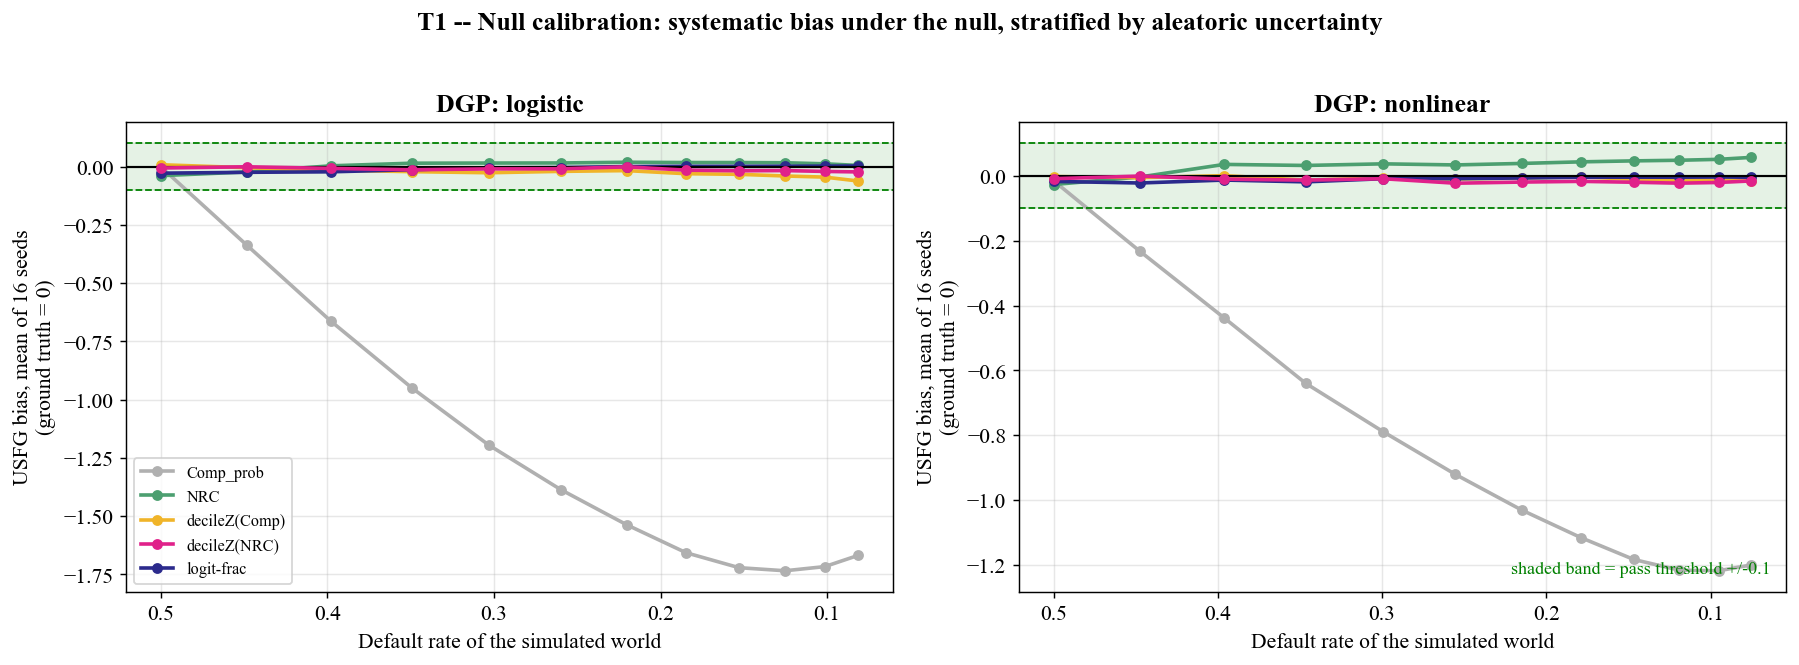

In [72]:
# --- fig17: null calibration across the default-rate sweep --------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, dgp in zip(axes, DGPS):
    sub = table11[table11["DGP"] == dgp]
    for name in METRICS:
        # Aggregate by INTERCEPT (one cell = 16 seeds), not by BaseRate: each seed yields a
        # slightly different realised default rate, so aggregating by it would leave one seed per
        # point and the resulting curve would show noise rather than bias.
        g = (sub[sub["Metric"] == name]
             .groupby("Intercept")
             .agg(br=("BaseRate", "mean"), bias=("USFG_by_aleatoric", "mean"))
             .sort_values("br"))
        ax.plot(g["br"].values, g["bias"].values, marker="o", ms=5, lw=2, label=name,
                color=METRIC_COLOR[name],
                zorder=5 if name == PROPOSED else 2)
    ax.axhline(0, color="black", lw=1.2)
    ax.axhspan(-NULL_TOL, NULL_TOL, color="green", alpha=0.10, zorder=0)
    ax.axhline(NULL_TOL, color="green", lw=1, ls="--")
    ax.axhline(-NULL_TOL, color="green", lw=1, ls="--")
    ax.set_xlabel("Default rate of the simulated world")
    ax.set_ylabel(f"USFG bias, mean of {N_SEEDS_T1} seeds\n(ground truth = 0)")
    ax.set_title(f"DGP: {dgp}", fontweight="bold")
    ax.invert_xaxis()
axes[0].legend(fontsize=9, loc="best")
axes[1].text(0.98, 0.04, f"shaded band = pass threshold +/-{NULL_TOL}",
             transform=axes[1].transAxes, ha="right", fontsize=10, color="green")
fig.suptitle("T1 -- Null calibration: systematic bias under the null, stratified by aleatoric "
             "uncertainty", fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "fig17_usfg_null_calibration")


--- fig18_usfg_dose_response ---
Saved to: ../result/figure/fig18_usfg_dose_response.png


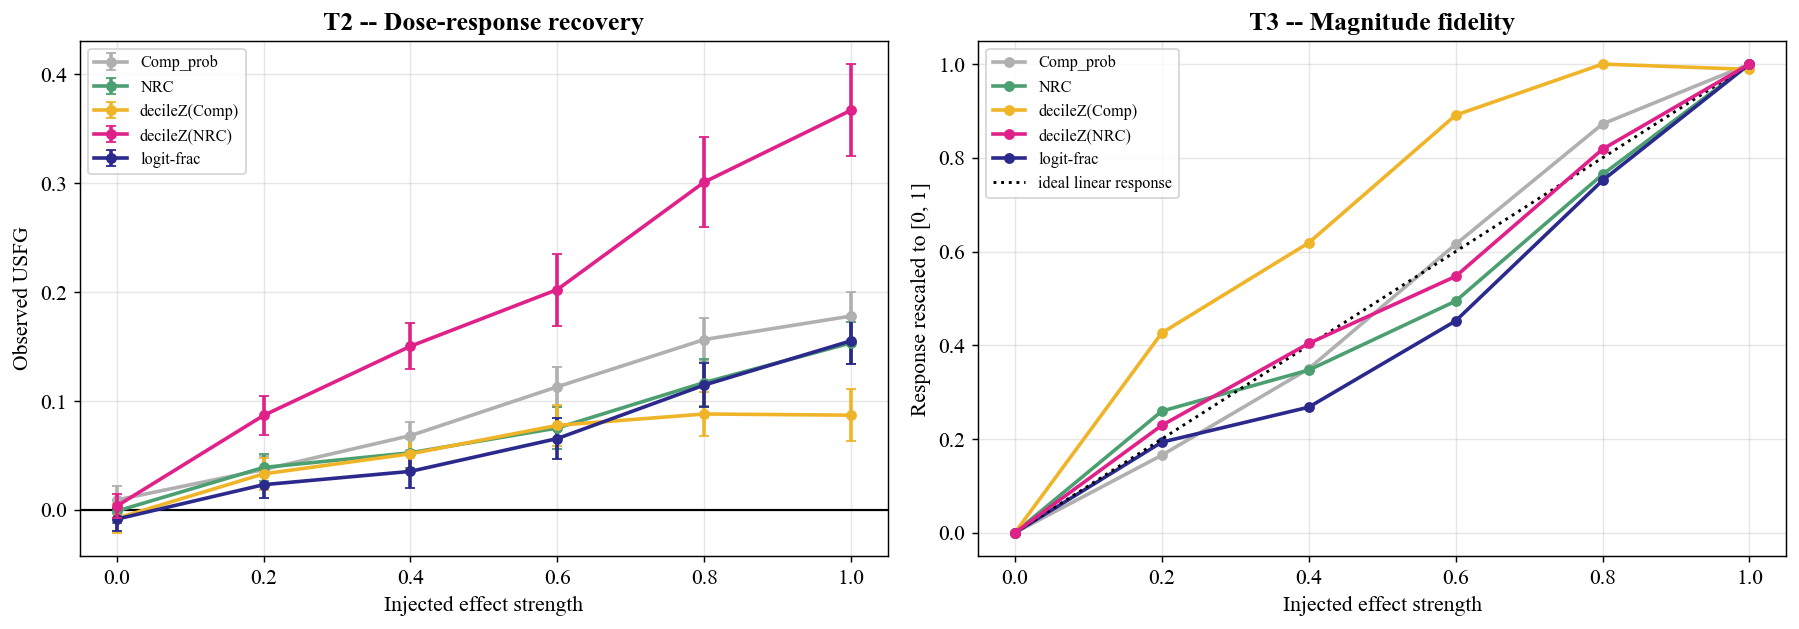

In [73]:
# --- fig18: dose-response ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in METRICS:
    g = table12[table12["Metric"] == name].groupby("Strength")["USFG"]
    m, se = g.mean().reindex(STRENGTHS), g.sem().reindex(STRENGTHS)
    axes[0].errorbar(STRENGTHS, m.values, yerr=1.96 * se.values, marker="o", ms=5, lw=2,
                     capsize=3, label=name, color=METRIC_COLOR[name],
                     zorder=5 if name == PROPOSED else 2)
axes[0].axhline(0, color="black", lw=1.2)
axes[0].set_xlabel("Injected effect strength")
axes[0].set_ylabel("Observed USFG")
axes[0].set_title("T2 -- Dose-response recovery", fontweight="bold")
axes[0].legend(fontsize=9)

# rescaled to [0,1] to compare the SHAPE of the response independently of metric scale
for name in METRICS:
    m = table12[table12["Metric"] == name].groupby("Strength")["USFG"].mean().reindex(STRENGTHS)
    rng_ = m.max() - m.min()
    if abs(rng_) < 1e-12:
        continue
    axes[1].plot(STRENGTHS, (m.values - m.values[0]) / rng_, marker="o", ms=5, lw=2,
                 label=name, color=METRIC_COLOR[name], zorder=5 if name == PROPOSED else 2)
axes[1].plot([0, 1], [0, 1], color="black", ls=":", lw=1.6, label="ideal linear response")
axes[1].set_xlabel("Injected effect strength")
axes[1].set_ylabel("Response rescaled to [0, 1]")
axes[1].set_title("T3 -- Magnitude fidelity", fontweight="bold")
axes[1].legend(fontsize=9)

fig.tight_layout()
save(fig, "fig18_usfg_dose_response")


--- fig19_fb5_verdict ---
Saved to: ../result/figure/fig19_fb5_verdict.png


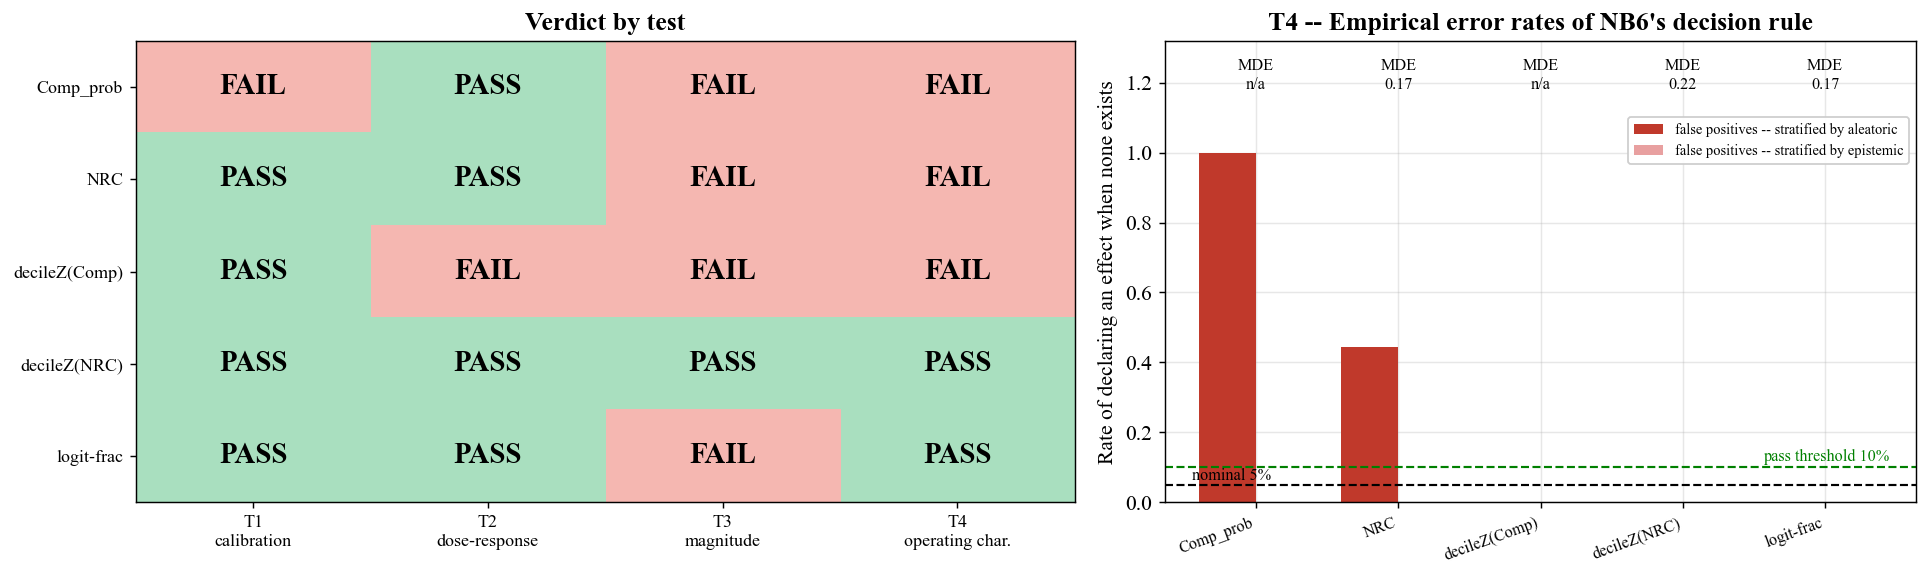

In [74]:
# --- fig19: verdict matrix + false-positive rates ------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6),
                         gridspec_kw={"width_ratios": [1.25, 1]})

tests = ["T1_calibration", "T2_dose_response", "T3_magnitude", "T4_error_rates"]
M = verdict[tests].astype(float).values
ax = axes[0]
ax.imshow(M, cmap=PASSFAIL_CMAP, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(tests)))
ax.set_xticklabels(["T1\ncalibration", "T2\ndose-response", "T3\nmagnitude",
                    "T4\noperating char."], fontsize=10)
ax.set_yticks(range(len(METRICS)))
ax.set_yticklabels(METRICS, fontsize=10)
for i in range(len(METRICS)):
    for j in range(len(tests)):
        ax.text(j, i, "PASS" if M[i, j] else "FAIL", ha="center", va="center",
                fontsize=16, fontweight="bold")
ax.set_title("Verdict by test", fontweight="bold")
ax.grid(False)

ax = axes[1]
x = np.arange(len(METRICS))
ax.bar(x - 0.2, table14["FPR_aleatoric"].values, 0.4,
       label="false positives -- stratified by aleatoric", color="#C0392B")
ax.bar(x + 0.2, table14["FPR_epistemic"].values, 0.4,
       label="false positives -- stratified by epistemic", color="#E8A0A0")
ax.axhline(0.05, color="black", ls="--", lw=1.2)
ax.text(-0.45, 0.065, "nominal 5%", ha="left", fontsize=9)
ax.axhline(FPR_MAX, color="green", ls="--", lw=1.2)
ax.text(len(METRICS) - 0.55, FPR_MAX + 0.02, f"pass threshold {FPR_MAX:.0%}", ha="right",
        fontsize=9, color="green")
for xi, m in enumerate(METRICS):
    mde = table14.loc[m, "MDE_at_80pct_power"]
    ax.text(xi, 1.27, "MDE\n" + (f"{mde:.2f}" if np.isfinite(mde) else "n/a"),
            ha="center", va="top", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(METRICS, rotation=20, ha="right", fontsize=9)
ax.set_ylim(0, 1.32)
ax.set_ylabel("Rate of declaring an effect when none exists")
ax.set_title("T4 -- Empirical error rates of NB6's decision rule", fontweight="bold")
ax.legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.0, 0.85), framealpha=0.95)

fig.tight_layout()
save(fig, "fig19_fb5_verdict")


--- fig20_twin_world_thresholds ---
Saved to: ../result/figure/fig20_twin_world_thresholds.png


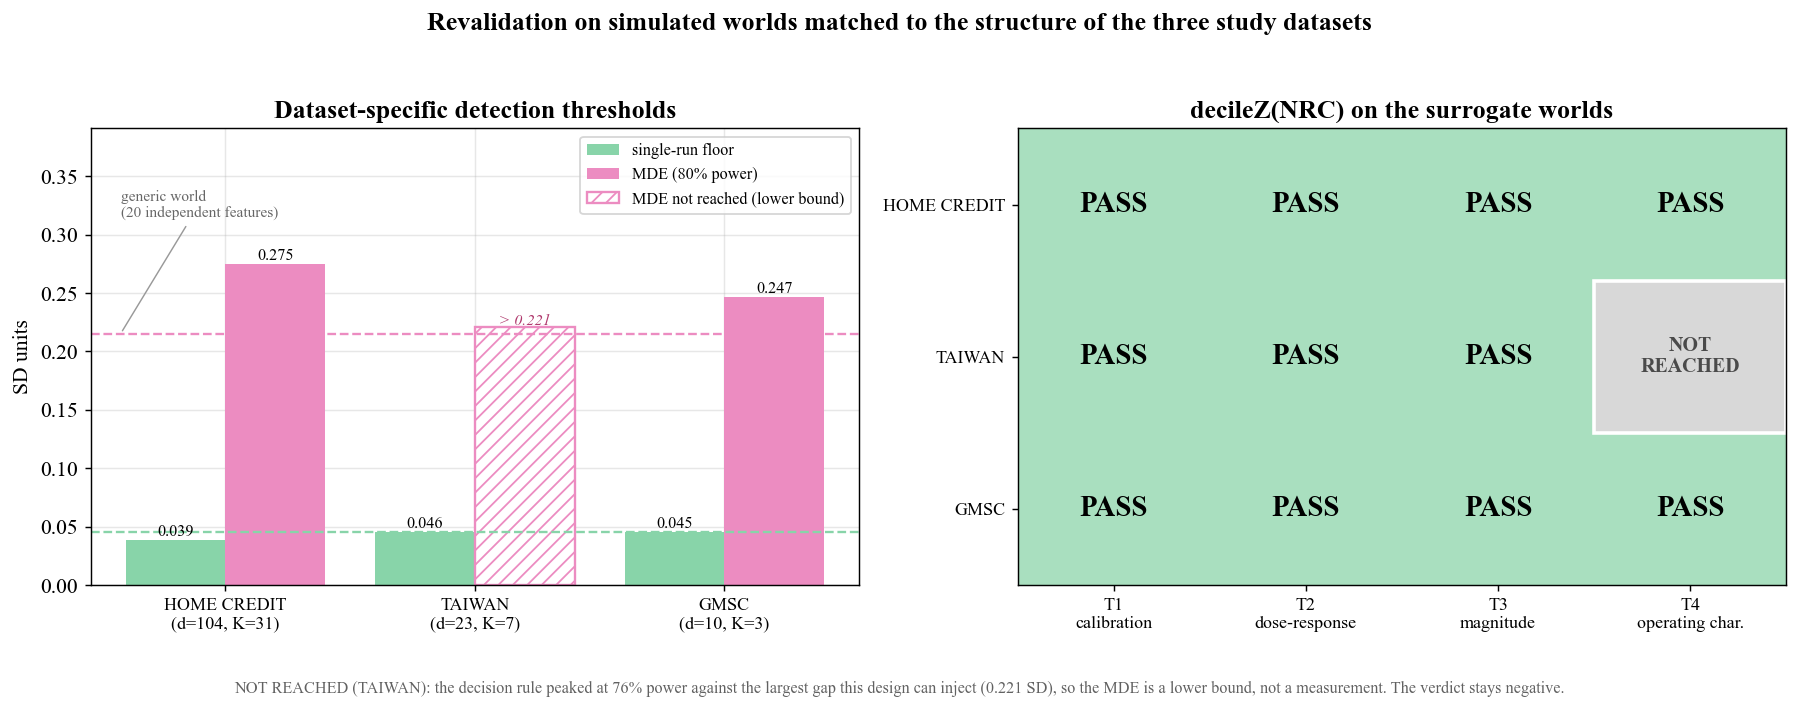

In [75]:
from matplotlib.patches import Rectangle
# --- fig20: dataset-specific detection thresholds ------------------------------------------
if TWIN_OK:
    prop = table17[table17.Metric == PROPOSED].set_index("Dataset")
    order = [d for d in ["HOME CREDIT", "TAIWAN", "GMSC"] if d in prop.index]
    prop = prop.loc[order]
    generic = pd.read_csv(f"{TABLE_DIR}/table15_fb5_verdict.csv").set_index("Metric")
    g_floor = float(generic.loc[PROPOSED, "single_run_floor"])
    g_mde = float(generic.loc[PROPOSED, "MDE"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    x = np.arange(len(prop))

    # A censored cell has no MDE: power never reached 80% within the range of gaps the
    # surrogate world can produce. Drawing nothing would read as "zero", and drawing it
    # like the others would read as a measurement, so it is drawn as a hatched bar at the
    # largest gap tested and labelled as the lower bound that it is.
    cens = prop["T4_censored"].values.astype(bool) if "T4_censored" in prop.columns \
        else np.zeros(len(prop), bool)
    mde_v = prop["T4_MDE"].values.astype(float)
    lb_v = prop["T4_max_gap_tested"].values.astype(float) if "T4_max_gap_tested" in prop.columns \
        else np.full(len(prop), np.nan)

    ax = axes[0]
    ax.bar(x - 0.2, prop["T1_single_run_floor"].values, 0.4, label="single-run floor",
           color="#88D4A9")
    ax.bar(x + 0.2, np.where(cens, np.nan, mde_v), 0.4, label="MDE (80% power)",
           color="#EC8CC1")
    ax.bar(x[cens] + 0.2, lb_v[cens], 0.4, color="white", edgecolor="#EC8CC1",
           hatch="///", lw=1.3, label="MDE not reached (lower bound)")
    ax.axhline(g_floor, color="#88D4A9", ls="--", lw=1.3)
    ax.axhline(g_mde, color="#EC8CC1", ls="--", lw=1.3)
    y_top = max(np.nanmax(np.where(cens, lb_v, mde_v)), g_mde) * 1.42
    ax.set_ylim(0, y_top)
    # Placed above every bar so the longer English caption cannot collide with the
    # tallest bar or its value label.
    ax.annotate("generic world\n(20 independent features)",
                xy=(-0.42, g_mde), xytext=(-0.42, y_top * 0.80),
                fontsize=8.5, color="#666666", ha="left", va="bottom",
                arrowprops=dict(arrowstyle="-", color="#999999", lw=0.8))
    for xi, f_ in enumerate(prop["T1_single_run_floor"].values):
        ax.text(xi - 0.2, f_, f"{f_:.3f}", ha="center", va="bottom", fontsize=9)
        if cens[xi]:
            ax.text(xi + 0.2, lb_v[xi], f"> {lb_v[xi]:.3f}", ha="center", va="bottom",
                    fontsize=9, style="italic", color="#B03A6E")
        else:
            ax.text(xi + 0.2, mde_v[xi], f"{mde_v[xi]:.3f}", ha="center", va="bottom",
                    fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}\n(d={int(prop['d'].iloc[k])}, "
                        f"K={int(prop['K_masked'].iloc[k])})"
                        for k, i in enumerate(prop.index)], fontsize=10)
    ax.set_ylabel("SD units")
    ax.set_title("Dataset-specific detection thresholds", fontweight="bold")
    ax.legend(fontsize=9)

    ax = axes[1]
    tests = ["T1_PASS", "T2_PASS", "T3_PASS", "T4_PASS"]
    M = prop[tests].astype(float).values
    ax.imshow(M, cmap=PASSFAIL_CMAP, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(4))
    ax.set_xticklabels(["T1\ncalibration", "T2\ndose-response", "T3\nmagnitude",
                        "T4\noperating char."], fontsize=10)
    ax.set_yticks(range(len(prop)))
    ax.set_yticklabels(prop.index, fontsize=10)
    # A censored T4 is neither a pass nor a measured failure: the quantity the test
    # grades could not be measured on this structure. It keeps its FALSE verdict in the
    # table but is drawn as its own state so it is not read as a measured shortfall.
    for i in range(len(prop)):
        if cens[i]:
            ax.add_patch(Rectangle((3 - .5, i - .5), 1, 1, facecolor="#D8D8D8",
                                   edgecolor="white", lw=2, zorder=2))
    for i in range(len(prop)):
        for j in range(4):
            if j == 3 and cens[i]:
                ax.text(j, i, "NOT\nREACHED", ha="center", va="center", fontsize=11,
                        fontweight="bold", color="#4A4A4A", zorder=3)
            else:
                ax.text(j, i, "PASS" if M[i, j] else "FAIL", ha="center", va="center",
                        fontsize=16, fontweight="bold", zorder=3)
    ax.set_title(f"{PROPOSED} on the surrogate worlds", fontweight="bold")
    ax.grid(False)

    fig.suptitle("Revalidation on simulated worlds matched to the structure of the three "
                 "study datasets", fontweight="bold", y=1.03)
    if cens.any():
        who = ", ".join(prop.index[cens])
        ax_note = (f"NOT REACHED ({who}): the decision rule peaked at "
                   f"{prop['T4_max_power'].values[cens][0]:.0%} power against the largest gap "
                   f"this design can inject ({lb_v[cens][0]:.3f} SD), so the MDE is a lower "
                   f"bound, not a measurement. The verdict stays negative.")
        fig.text(0.5, -0.06, ax_note, ha="center", fontsize=9, color="#616161", wrap=True)
    fig.tight_layout()
    save(fig, "fig20_twin_world_thresholds")

## 11. Using these results in the manuscript

1. **Present this as a dedicated methods section**, not as an appendix. FB5 is the most serious of
   the six reviewer comments and the only one that cannot be resolved by rewriting text; this
   section is the response to it.
2. **Report the failures — they carry the argument.** The single most valuable number in this
   notebook is in `table14`: the false-positive rate of `Comp_prob` under aleatoric stratification.
   It demonstrates empirically that the metric used in the proposal declares a faithfulness gap in
   worlds **constructed so that no gap can exist**. This is not a weakness of the study; it is the
   argument that calibrating the metric is mandatory, and it aligns exactly with the concern raised
   in FB2/FB3 regarding perturbation-based faithfulness measures. Omitting the failures would
   forfeit that argument.
3. **Carry two thresholds into the results chapter**, from `table15`:
   - the *single-run floor* — an observed USFG below it must be described as **"not distinguishable
     from zero"**, never as "zero" or "no effect";
   - the *MDE* — any negative result whose magnitude falls below the MDE establishes only **"not
     detectable at this sample size"**, not absence. This applies directly to the conclusion about
     epistemic uncertainty in RQ1, which must be stated as a *power-limited* negative result rather
     than as affirmative evidence for the null hypothesis.
4. **Use DATASET-SPECIFIC thresholds** (`table17`, `fig20`) rather than a single pooled value.
   Masking 31 of 104 features in Home Credit does not confer the same sensitivity as masking 3 of
   10 in GMSC, and Section 9 quantifies that difference. Stating this is itself a secondary
   contribution: *the sensitivity of the design depends on dimensionality, and we quantify that
   dependence.*
5. **State the remaining limitations explicitly.** After Section 9 the validated envelope covers
   the dimensionality, correlation structure, marginal distributions and default rates of the three
   study datasets. Three aspects remain **outside** it and must be reported:
   - the risk function in the simulation is author-specified and does not represent a real causal
     mechanism;
   - baseline-state explanations are **exact** first-order contributions, whereas SHAP in practice
     is a noisy approximation (Jaccard 0.74 on Home Credit — see `table2b`);
   - the injected effect is **orthogonal to `p` by construction**. With observational data, a true
     effect perfectly collinear with the confound `p(1-p)` is **unidentifiable in principle** —
     a limitation of the inferential problem rather than of the metric, but one that must be
     stated.

   A modest claim proved completely is stronger than an ambitious claim the evidence cannot
   support.